#### This project analyzes student academic data to explore how factors such as gender and parental education influence student performance and scores.

#### The goal of this project is to uncover patterns in the data that can inform educational policies and help improve student performance.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.patches as mpatches

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')
# # Statistical Analysis
# import scipy.stats as stats
# import statsmodels.api as sm
# from statsmodels.formula.api import ols
# import statsmodels.formula.api as smf


# Dataset import

This dataset provides insights into how different study habits, learning styles, and external factors influence student performance. It includes over 20,000 records, covering details about students' study hours, in-class participation, exam scores, and other factors impacting academic success.

#### Dataset Features:
 0.   **Age:**      The age of the student (18-30 years).  
 1.   **Assignment_Score:**   Average score of all assignments (out of 100).
 2.   **Attendance_Score:** Attendance percentage (0-100%).
 3.   **Distance_from_Home:** Distance from home to school (Near, Moderate, Far).    
 4.   **Exam_Score:** Student’s final exam score (0-100%).         
 5.   **Extracurricular:** Whether the student participates in extracurriculars (Yes/No).       
 6.   **Family_Income:** Family income level (Low, Medium, High).        
 7.   **Gender:**  Gender of the student (Male, Female).              
 8.   **Grade:** Letter grade assigned grade based on exam score (A, B, C, D, F).                 
 9.   **Internet:**  Does the student have access to the internet at home? (Yes/No).
 10.  **Learning_Disabilities:** Presence of learning disabilities (Yes, No). 
 11.  **Motivation_Level:** Student's level of motivation (Low, Medium, High).
 12.  **Parent_Education:** Highest education level of parents (None, High School, College, PostGraduate).      
 13.  **Parental_Involvement:** Level of parental involvement in the student's education (Low, Medium, High).   
 14.  **Participation:**  Whether the student actively participates in discussions (Yes/No).          
 15.  **Peer_Influence:** Influence of peers on academic performance (Positive, Neutral, Negative).        
 16.  **Physical_Activity:**   Average number of hours of physical activity per week. 
 17.  **Resources:**  Availability of educational resources (Low, Medium, High). 
 18.  **Sleep_Hours:** Average number of hours of sleep per night.            
 19.  **Social_Media:**   Weekly hours spent on social media (0-30 hours)  
 20.  **Stress_Level:** Student’s stress level (Low, Medium, High).         
 21.  **Study_Hours_per_Week:** Average study hours per week.
 22.  **Teacher_Quality:** Quality of the teachers (Low, Medium, High).         
 23.  **Total_Score:** Weighted sum of all grades (0-100%) .          
 24.  **Tutoring_Sessions:**  Number of tutoring sessions attended per month.

In [2]:
df = pd.read_csv("C:/Users/ASUS/Documents/1-Medtech/Final/CS434- Data Mining/Project/student_performance_dataset.csv")
df.head()

,Age,Assignment_Score,Attendance_Score,Distance_from_Home,Exam_Score,Extracurricular,Family_Income,Gender,Grade,Internet,...,Peer_Influence,Physical_Activity,Resources,Sleep_Hours,Social_Media,Stress_Level,Study_Hours_per_Week,Teacher_Quality,Total_Score,Tutoring_Sessions
0,22,73.0,84.0,Near,67.0,No,Low,Male,C,Yes,...,Positive,3,High,7,5,High,22,Medium,72.2,0
1,23,59.0,64.0,Moderate,61.0,No,Medium,Female,D,Yes,...,Negative,4,Medium,8,0,High,18,Medium,61.0,2
2,22,91.0,98.0,Near,74.0,Yes,Medium,Male,B,Yes,...,Neutral,4,Medium,7,8,High,23,Medium,83.9,2
3,22,98.0,89.0,Moderate,71.0,Yes,Medium,Male,B,Yes,...,Negative,4,Medium,8,5,High,28,Medium,82.7,1
4,25,65.0,92.0,Near,70.0,Yes,Medium,Female,C,Yes,...,Neutral,4,Medium,6,4,Medium,18,High,72.9,3


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21201 entries, 0 to 21200
Data columns (total 25 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    21201 non-null  int64  
 1   Assignment_Score       21201 non-null  float64
 2   Attendance_Score       21201 non-null  float64
 3   Distance_from_Home     21201 non-null  object 
 4   Exam_Score             21201 non-null  float64
 5   Extracurricular        21201 non-null  object 
 6   Family_Income          21201 non-null  object 
 7   Gender                 21201 non-null  object 
 8   Grade                  21201 non-null  object 
 9   Internet               21201 non-null  object 
 10  Learning_Disabilities  21201 non-null  object 
 11  Motivation_Level       21201 non-null  object 
 12  Parent_Education       21201 non-null  object 
 13  Parental_Involvement   21201 non-null  object 
 14  Participation          21201 non-null  object 
 15  Pe

In [4]:
num_duplicates = df.duplicated().sum()
print("Number of duplicate rows:", num_duplicates)


Number of duplicate rows: 0


# Outliers handling

1. Visualize outliers for a numeric column in df.
1. Count min, max, and outlier values.
1. Visualize other features of the students in each of these groups.

In [5]:
df.describe()

,Age,Assignment_Score,Attendance_Score,Exam_Score,Physical_Activity,Sleep_Hours,Social_Media,Study_Hours_per_Week,Total_Score,Tutoring_Sessions
count,21201.000000,21201.000000,21201.000000,21201.000000,21201.000000,21201.000000,21201.000000,21201.000000,21201.000000,21201.000000
mean,22.979482,74.974982,76.669992,69.250366,1.380878,6.879581,11.716193,21.627753,72.236031,4.640111
std,3.255692,14.525428,13.917029,13.516739,1.754609,1.746554,9.384223,10.835390,8.455846,2.671955
min,18.000000,50.000000,50.000000,40.000000,0.000000,4.000000,0.000000,0.000000,45.600000,0.000000
25%,20.000000,62.300000,65.000000,62.000000,0.000000,6.000000,2.000000,14.000000,66.500000,2.000000
50%,23.000000,75.000000,77.000000,68.000000,0.000000,7.000000,11.000000,20.000000,72.200000,6.000000
75%,25.000000,87.800000,89.000000,77.000000,3.000000,8.000000,19.000000,27.000000,77.900000,7.000000
max,29.000000,100.000000,100.000000,101.000000,6.000000,10.000000,30.000000,48.000000,99.200000,8.000000


Total Below IQR outliers: 40, range: [45.6-49.3]
Total Above IQR outliers: 61, range: [95.1-99.2]


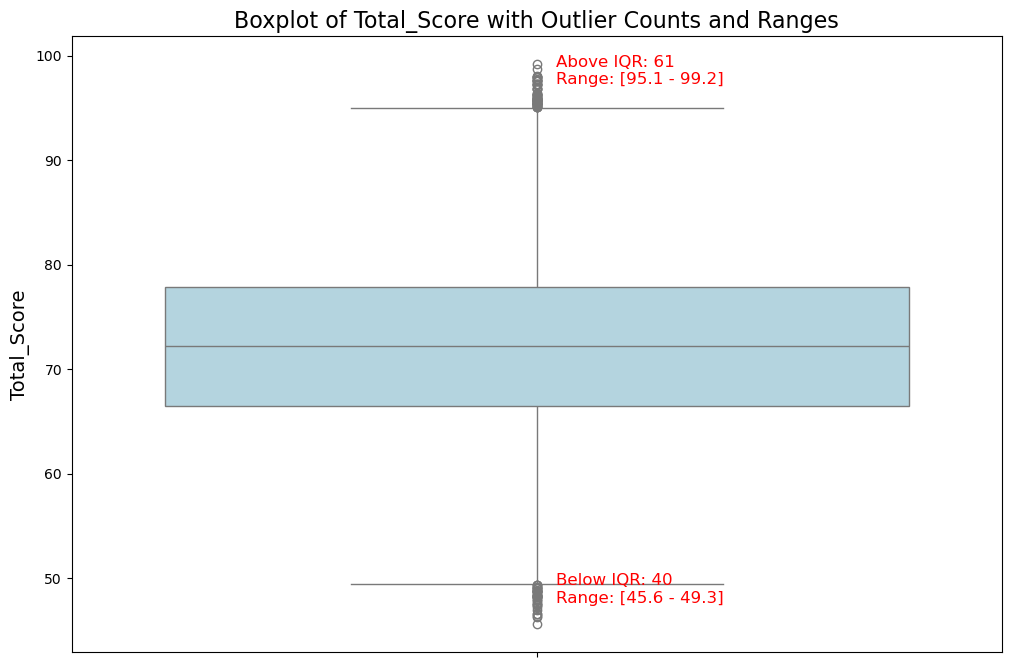

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

col = 'Total_Score'  # column to analyze

# --- 1. Calculate quartiles and IQR ---
Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# --- 2. Label outliers ---
def label_outlier(x):
    if x < lower_bound:
        return 'Below IQR'
    elif x > upper_bound:
        return 'Above IQR'
    else:
        return 'Normal'

df['Outlier_Group'] = df[col].apply(label_outlier)

# --- 3. Count each group ---
group_counts = df['Outlier_Group'].value_counts()
count_below = group_counts.get('Below IQR', 0)
count_above = group_counts.get('Above IQR', 0)

# --- 3b. Min/Max among outliers ---
below_outliers = df[df[col] < lower_bound][col]
above_outliers = df[df[col] > upper_bound][col]

min_below = below_outliers.min() if not below_outliers.empty else None
max_below = below_outliers.max() if not below_outliers.empty else None

min_above = above_outliers.min() if not above_outliers.empty else None
max_above = above_outliers.max() if not above_outliers.empty else None

print(f"Total Below IQR outliers: {count_below}, range: [{min_below}-{max_below}]")
print(f"Total Above IQR outliers: {count_above}, range: [{min_above}-{max_above}]")

# --- 4. Boxplot with annotated counts and ranges ---
plt.figure(figsize=(12,8))
sns.boxplot(y=df[col], color='lightblue')

# Annotate Below IQR
if count_below > 0:
    plt.text(
        x=0.02, y=lower_bound - 2, 
        s=f"Below IQR: {count_below}\nRange: [{min_below} - {max_below}]",
        color='red', fontsize=12, verticalalignment='bottom'
    )

# Annotate Above IQR
if count_above > 0:
    plt.text(
        x=0.02, y=upper_bound + 2, 
        s=f"Above IQR: {count_above}\nRange: [{min_above} - {max_above}]",
        color='red', fontsize=12, verticalalignment='bottom'
    )

plt.title('Boxplot of Total_Score with Outlier Counts and Ranges', fontsize=16)
plt.ylabel('Total_Score', fontsize=14)
plt.show()


#### Exploring how students labeled as outliers in Total_Score behave across other columns to analyze patterns

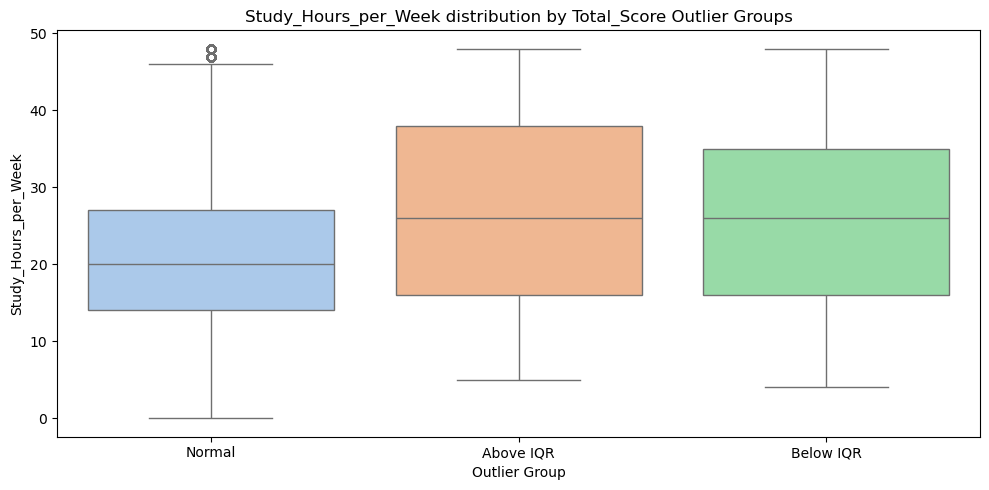

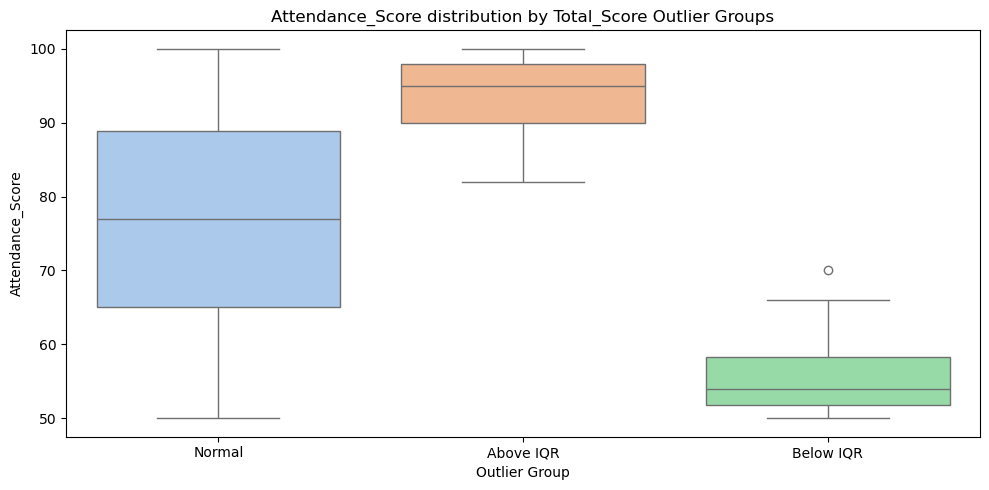

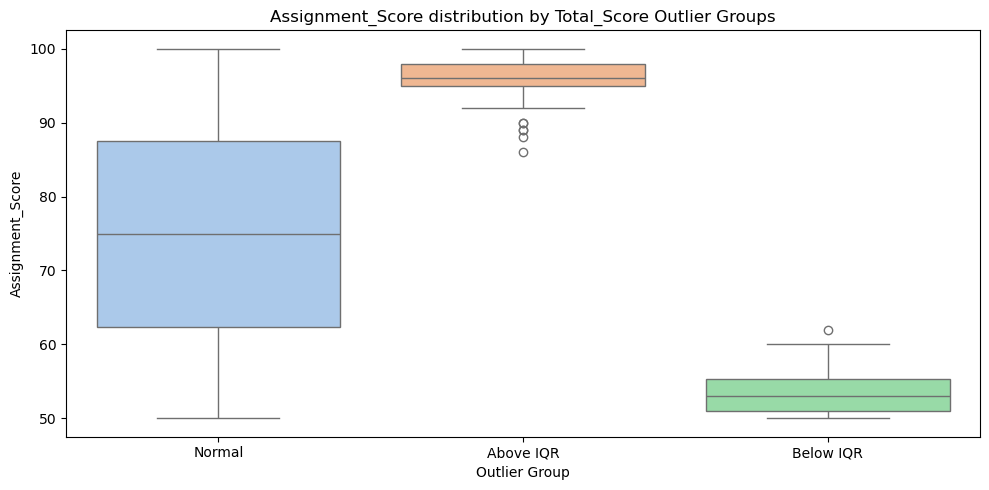

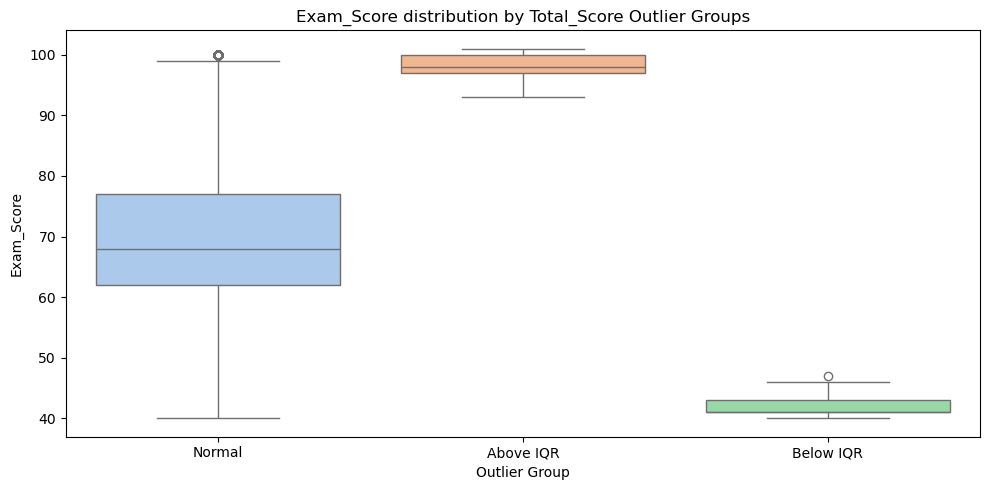

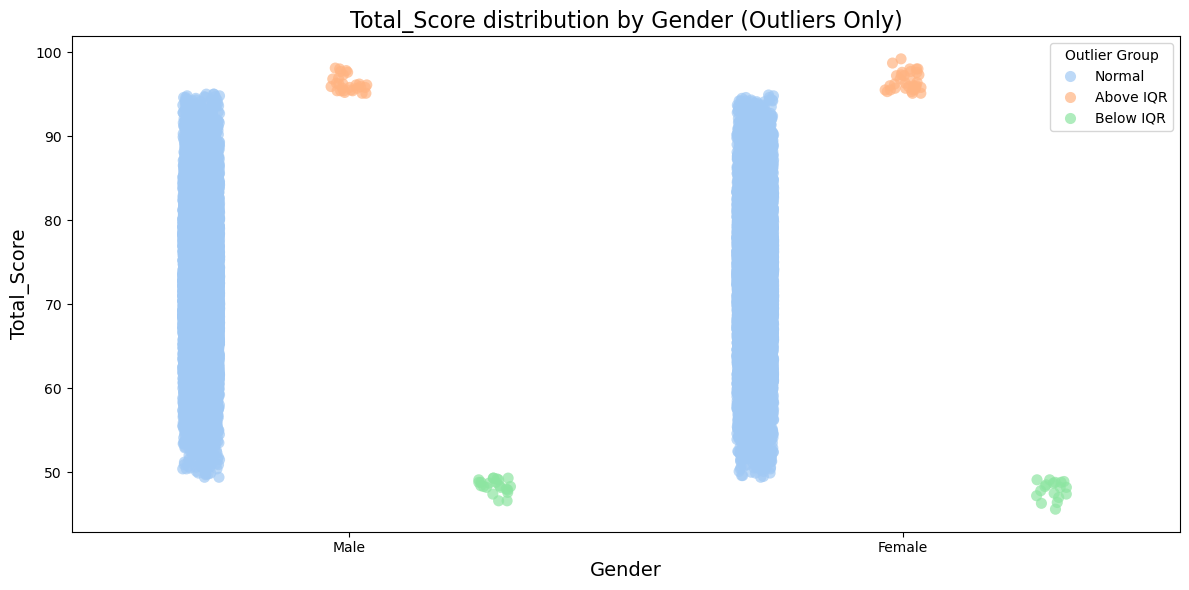

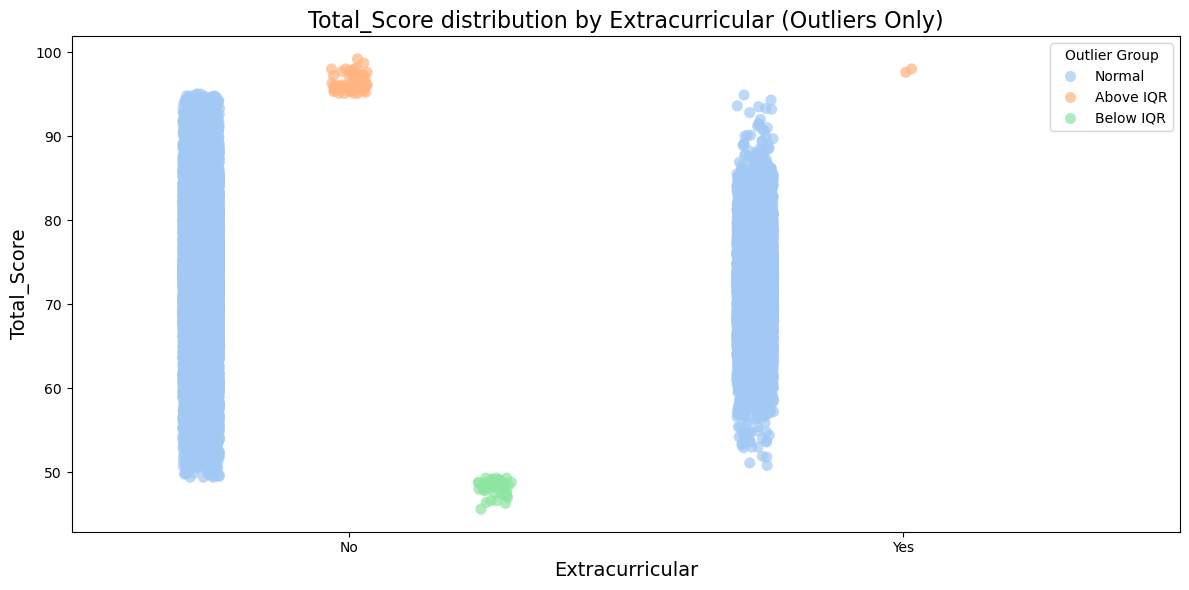

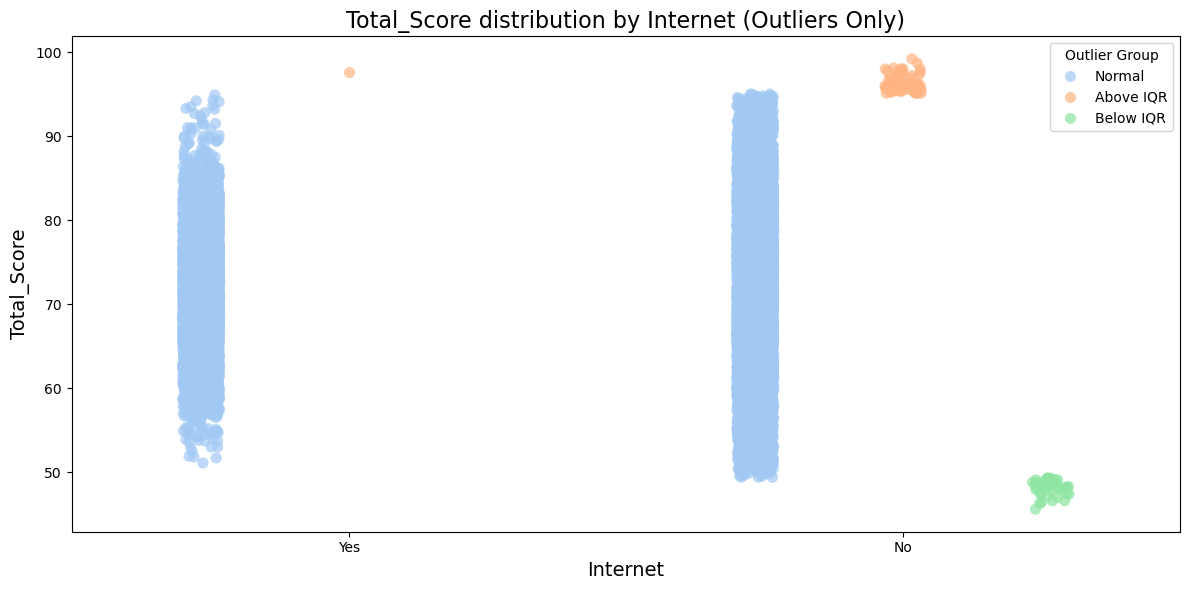

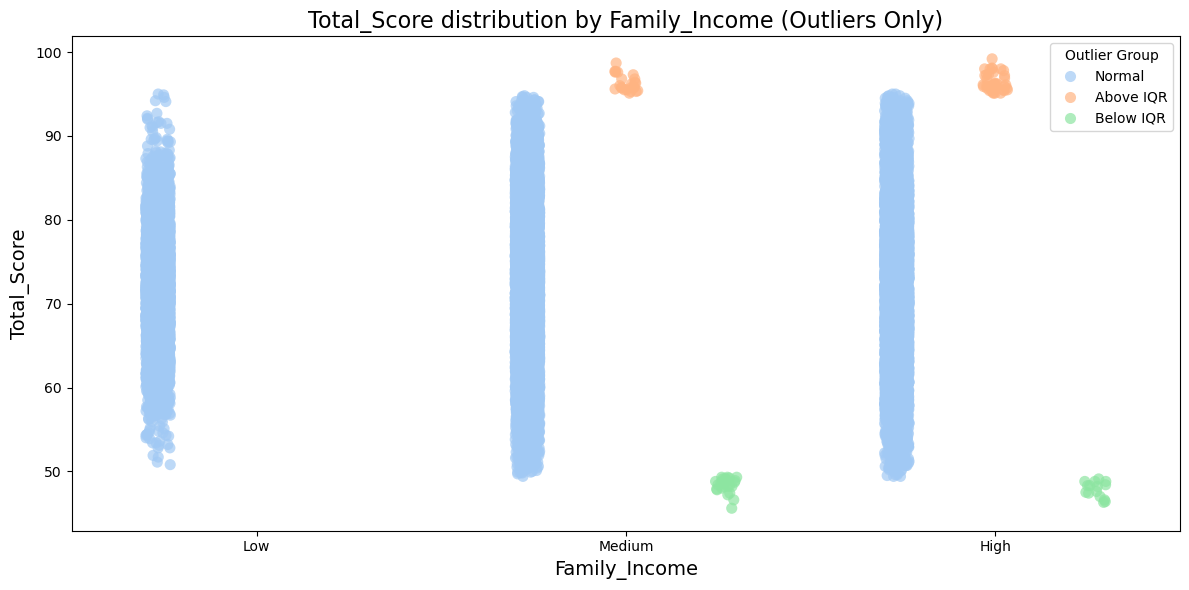

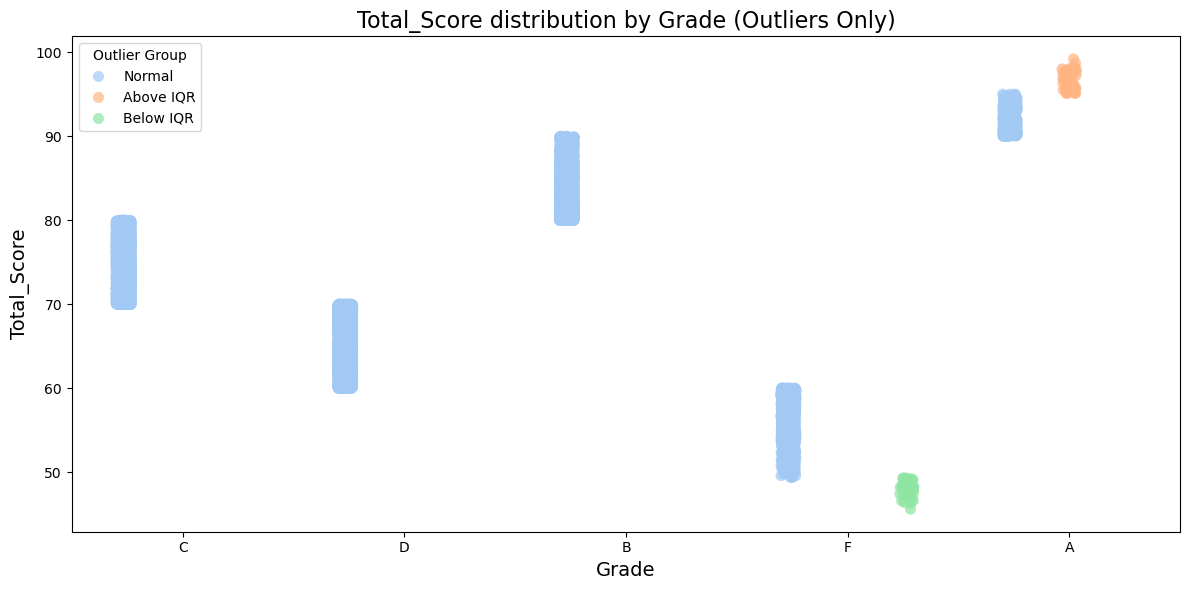

In [7]:
# --- 5. Boxplots of other numeric features by Outlier_Group ---
numeric_features = ['Study_Hours_per_Week', 'Attendance_Score', 'Assignment_Score', 'Exam_Score']

for feature in numeric_features:
    plt.figure(figsize=(10,5))
    sns.boxplot(x='Outlier_Group', y=feature, data=df, palette='pastel')
    plt.title(f'{feature} distribution by Total_Score Outlier Groups')
    plt.ylabel(feature)
    plt.xlabel('Outlier Group')
    plt.tight_layout()
    plt.show()

# --- 6. Visualize categorical features by Outlier_Group ---
categorical_features = ['Gender', 'Extracurricular', 'Internet', 'Family_Income', 'Grade']


for feature in categorical_features:
    plt.figure(figsize=(12,6))
    sns.stripplot(
        x=feature,
        y='Total_Score',
        hue='Outlier_Group',
        data=df,
        palette='pastel',
        jitter=True,   # spreads points to reduce overlap
        dodge=True,    # separate hues horizontally
        size=8,        # marker size
        alpha=0.7
    )
    plt.title(f'Total_Score distribution by {feature} (Outliers Only)', fontsize=16)
    plt.ylabel('Total_Score', fontsize=14)
    plt.xlabel(feature, fontsize=14)
    plt.legend(title='Outlier Group')
    plt.tight_layout()
    plt.show()

# EDA
## General patterns overview accross all students

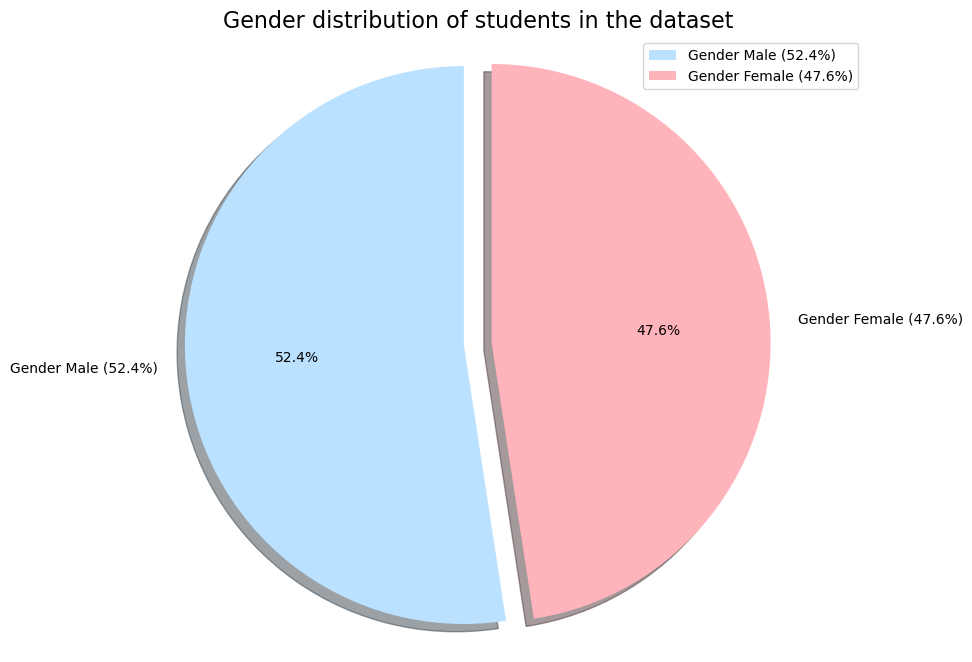

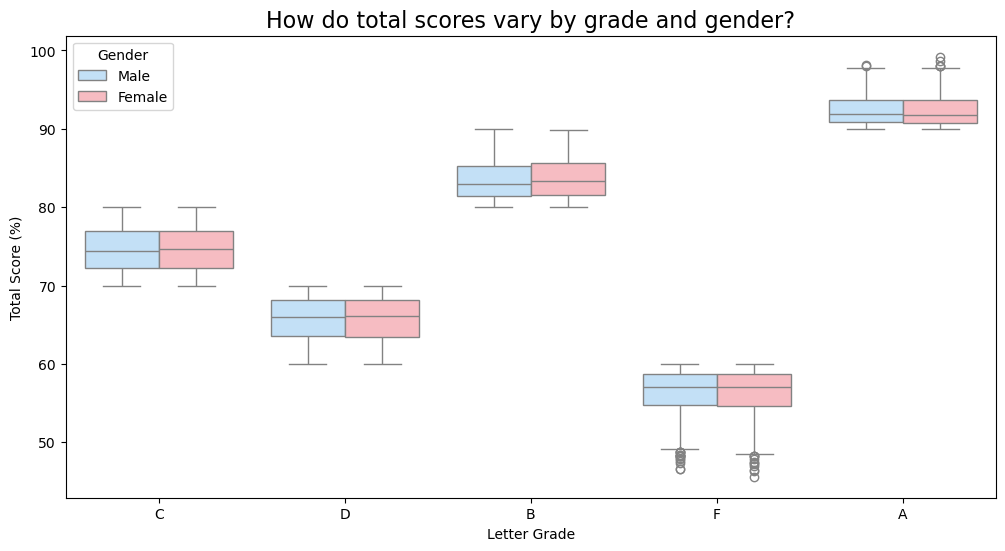

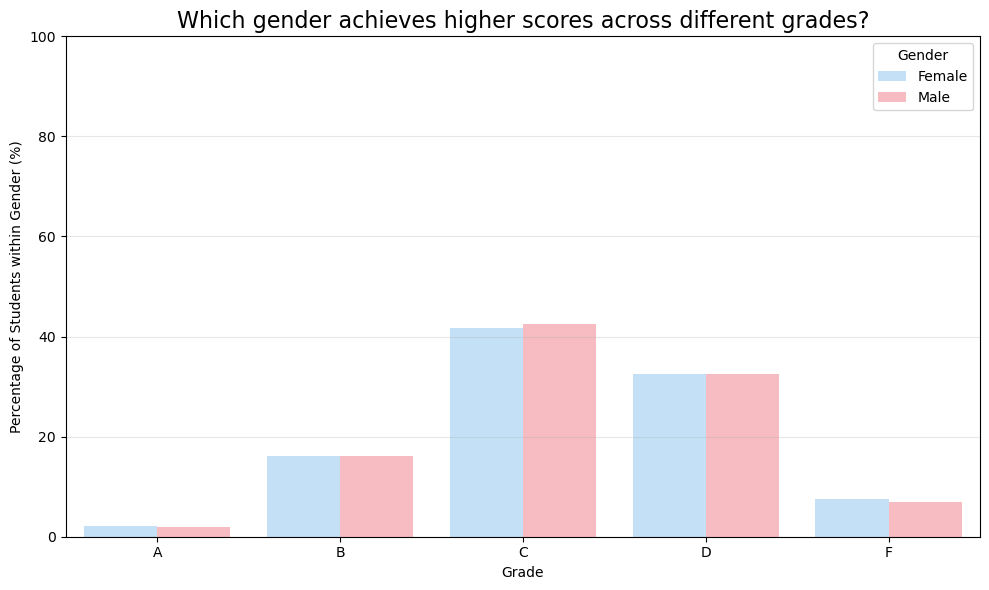

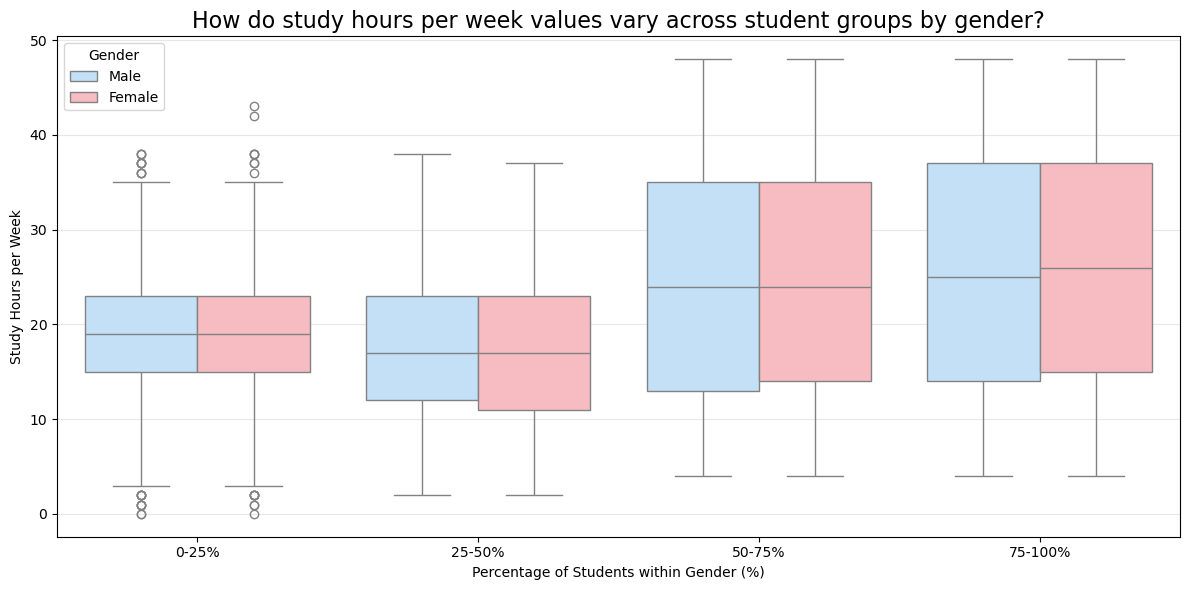

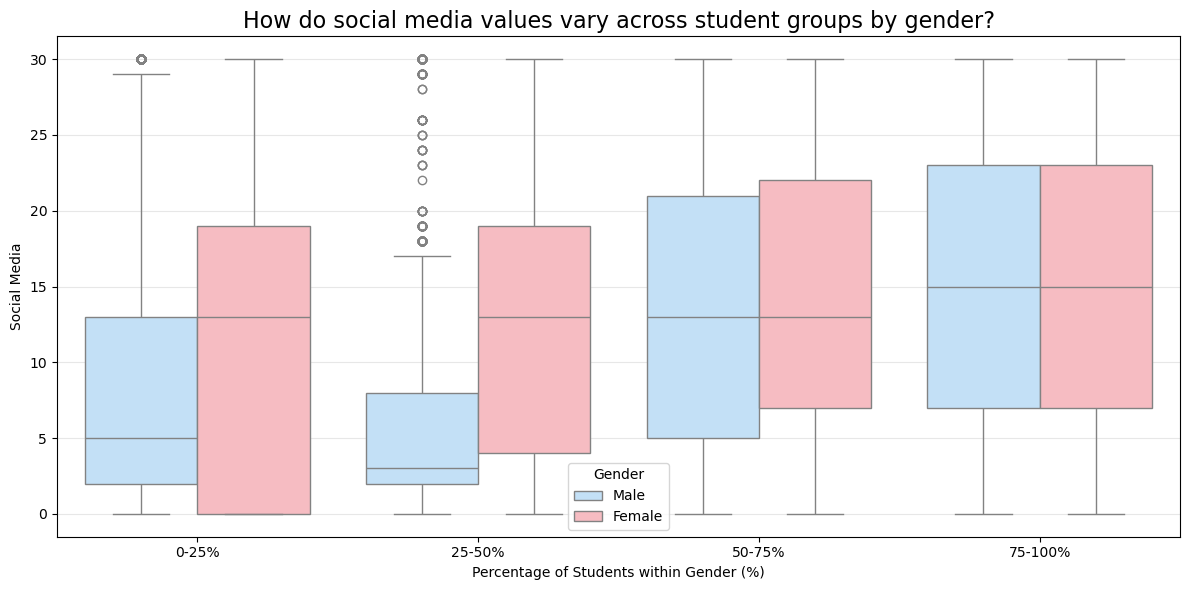

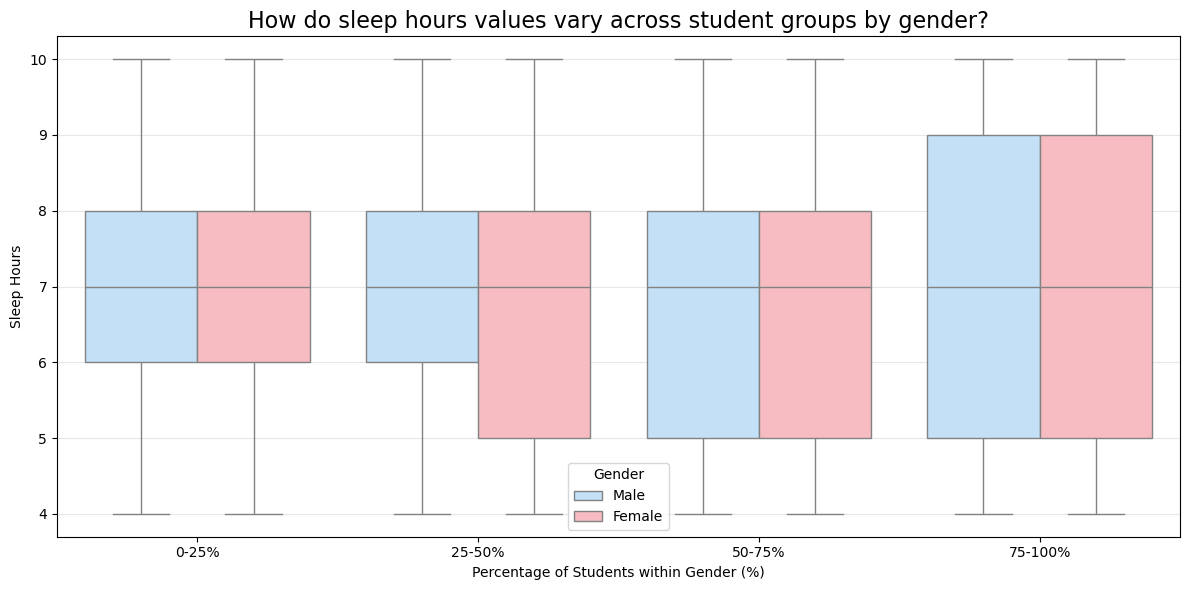

In [8]:
# Total records
total_records = len(df)

# Make a copy of the original DataFrame for visualization
df2 = df.copy()

# Create a dataset quartile column in df2
df2['Dataset_Quartile'] = pd.qcut(range(len(df2)), 4, labels=['0-25%','25-50%','50-75%','75-100%'])

colors = ['#BAE1FF', '#FFB3BA']  # Pastel colors for gender

# --- 1. Gender Distribution Pie Chart ---
plt.figure(figsize=(10, 8))
gender_counts = df['Gender'].value_counts()
total = gender_counts.sum()
percentages = [f'{(count/total)*100:.1f}%' for count in gender_counts]

plt.pie(
    gender_counts, 
    labels=[f'Gender {i} ({perc})' for i, perc in zip(gender_counts.index, percentages)],
    autopct='%1.1f%%',
    colors=colors,
    explode=[0.05] * len(gender_counts),  
    shadow=True,
    startangle=90
)
plt.title('Gender distribution of students in the dataset', fontsize=16)
plt.axis('equal') 
plt.legend()
plt.show()

# --- 2. Total Scores Distribution by Letter Grade and Gender ---
plt.figure(figsize=(12, 6))
sns.boxplot(x='Grade', y='Total_Score', hue='Gender', data=df, palette=colors)
plt.title('How do total scores vary by grade and gender?', fontsize=16)
plt.xlabel('Letter Grade')
plt.ylabel('Total Score (%)')
plt.legend(title='Gender')
plt.show()

# --- 3. Percentage of Students per Grade by Gender ---
grade_gender_counts = df2.groupby(['Grade', 'Gender']).size().reset_index(name='count')
grade_gender_counts['percent_of_gender'] = grade_gender_counts.groupby('Gender')['count'].transform(lambda x: x / x.sum() * 100)

plt.figure(figsize=(10,6))
sns.barplot(x='Grade', y='percent_of_gender', hue='Gender', data=grade_gender_counts, palette=colors)
plt.title('Which gender achieves higher scores across different grades?', fontsize=16)
plt.ylabel('Percentage of Students within Gender (%)')
plt.xlabel('Grade')
plt.ylim(0,100)
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# --- 4. Study hours, social media, and sleep patterns by dataset quartiles and gender ---
numeric_features = ['Study_Hours_per_Week', 'Social_Media', 'Sleep_Hours']

for feature in numeric_features:
    plt.figure(figsize=(12,6))
    sns.boxplot(
        x='Dataset_Quartile',
        y=feature,
        hue='Gender',
        data=df2,
        palette=colors
    )
    plt.title(f'How do {feature.replace("_", " ").lower()} values vary across student groups by gender?', fontsize=16)
    plt.xlabel('Percentage of Students within Gender (%)')
    plt.ylabel(feature.replace("_", " "))
    plt.legend(title='Gender')
    plt.grid(alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()
     
    # Add extra vertical space between plots
    plt.pause(0.5)  # optional small pause to make spacing clearer

## Structured EDA 
### Create a visualisation function

In [9]:
# Make a copy of the original DataFrame for visualization
df_vis = df.copy()

In [10]:

# --- General function to visualize one category ---
def visualize_category(df, columns, hue='Gender'):
    for col in columns:
        print(f"\nAnalyzing column: {col}")

        # --- Skip if col is same as hue for categorical ---
        if col == hue and df[col].dtype not in ['int64', 'float64']:
            print(f"Skipping column '{col}' because it is the same as hue '{hue}'.")
            continue

        # --- Numeric features ---
        if df[col].dtype in ['int64', 'float64']:
            plt.figure(figsize=(10,5))
            sns.boxplot(x=hue, y=col, data=df, palette=colors)
            plt.title(f'How does {col.replace("_"," ")} vary by {hue}?', fontsize=14)
            plt.ylabel(col.replace("_"," "))
            plt.xlabel(hue)
            plt.grid(alpha=0.3, axis='y')
            plt.tight_layout()
            plt.show()

            # Display basic statistics
            print(df[col].describe())

        # --- Categorical features ---
        else:
            plt.figure(figsize=(10,5))
            
            # Use only relevant columns to avoid conflicts
            temp = df[[col, hue]].copy()

            # Group and calculate counts
            cat_counts = temp.groupby([col, hue]).size().reset_index(name='cnt')
            cat_counts['percent_of_hue'] = cat_counts.groupby(hue)['cnt'].transform(lambda x: x / x.sum() * 100)

            # Barplot of percentages
            sns.barplot(x=col, y='percent_of_hue', hue=hue, data=cat_counts, palette=colors)
            plt.title(f'Distribution of {col.replace("_"," ")} by {hue}', fontsize=14)
            plt.ylabel(f'Percentage within {hue} (%)')
            plt.xlabel(col.replace("_"," "))
            plt.ylim(0,100)
            plt.grid(alpha=0.3, axis='y')
            plt.tight_layout()
            plt.show()

            # Print counts pivot table
            pivot_table = cat_counts.pivot(index=col, columns=hue, values='cnt').fillna(0)
            print(pivot_table)


### 1. Demographic Features

In [11]:
demographic_cols = [
    'Age',
    'Gender',
    'Family_Income',
    'Distance_from_Home',
    'Parent_Education',
    'Learning_Disabilities'
]


Analyzing column: Age


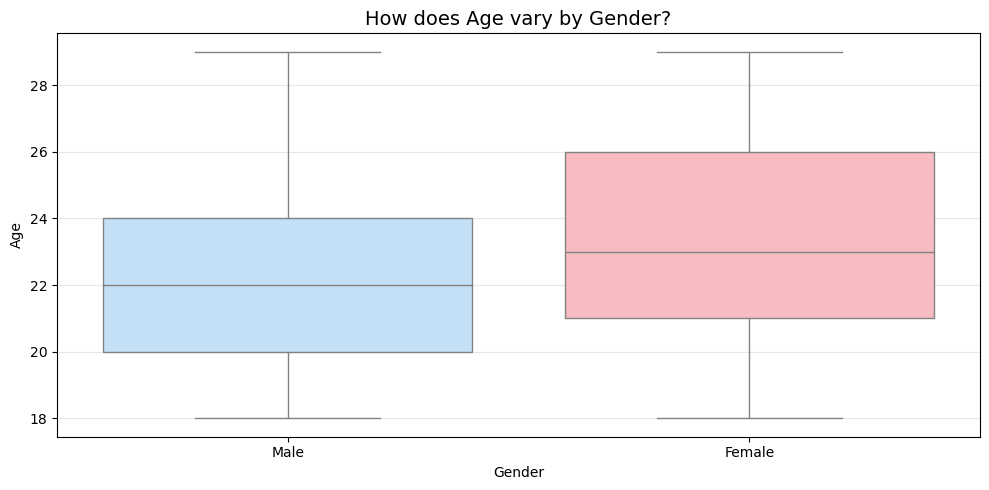

count    21201.000000
mean        22.979482
std          3.255692
min         18.000000
25%         20.000000
50%         23.000000
75%         25.000000
max         29.000000
Name: Age, dtype: float64

Analyzing column: Gender
Skipping column 'Gender' because it is the same as hue 'Gender'.

Analyzing column: Family_Income


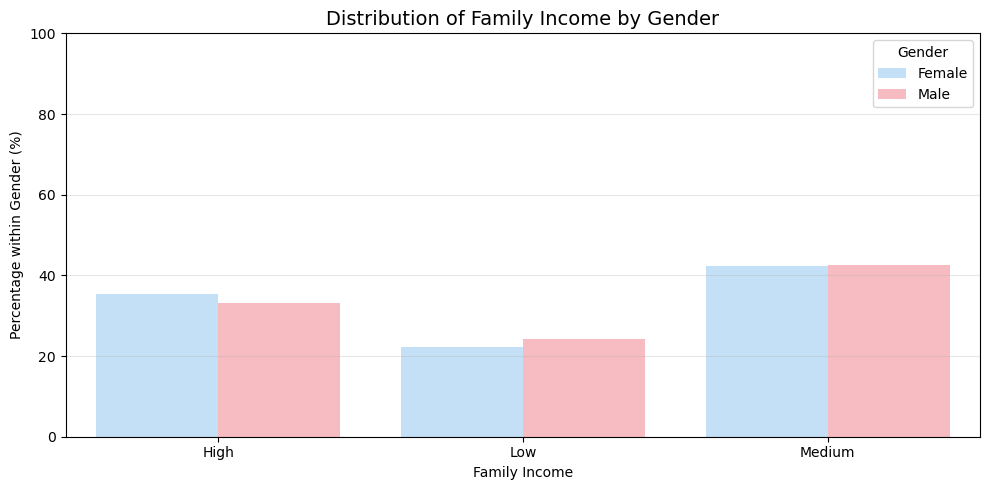

Gender         Female  Male
Family_Income              
High             3566  3695
Low              2255  2688
Medium           4267  4730

Analyzing column: Distance_from_Home


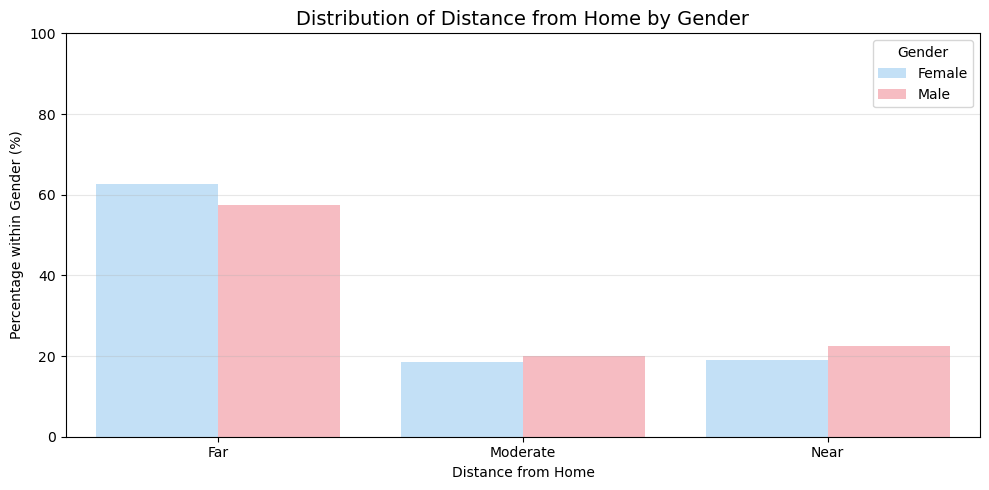

Gender              Female  Male
Distance_from_Home              
Far                   6318  6390
Moderate              1863  2230
Near                  1907  2493

Analyzing column: Parent_Education


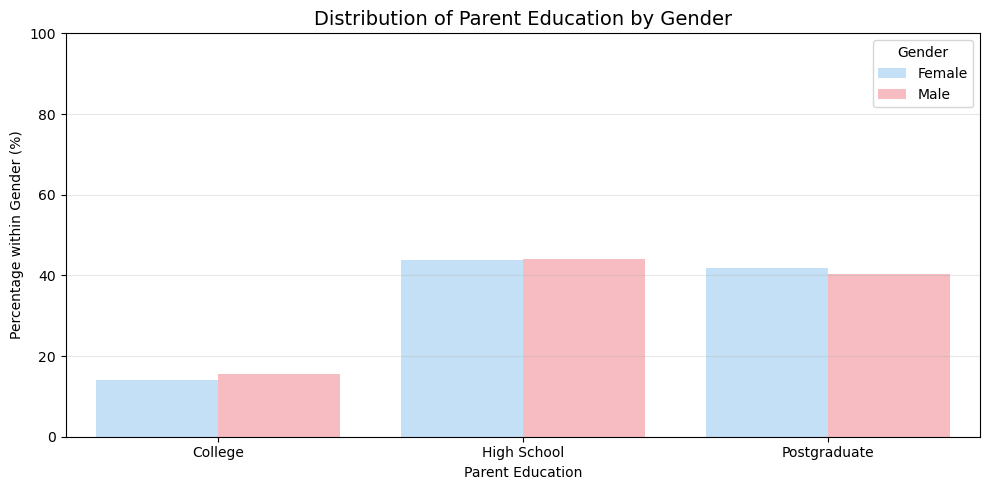

Gender            Female  Male
Parent_Education              
College             1431  1729
High School         4429  4890
Postgraduate        4228  4494

Analyzing column: Learning_Disabilities


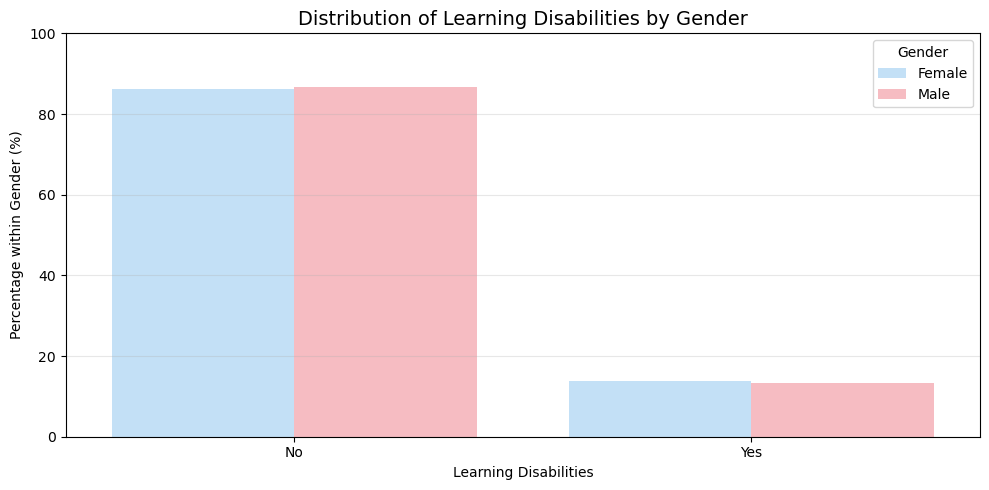

Gender                 Female  Male
Learning_Disabilities              
No                       8696  9632
Yes                      1392  1481


In [12]:
# --- Example usage: visualize demographic features ---
visualize_category(df_vis, demographic_cols)

### 2. Academic Performance

In [ ]:
academic_cols = [
    'Assignment_Score',
    'Attendance_Score',
    'Exam_Score',
    'Total_Score',
    'Grade',
    'Participation'
]


Analyzing column: Assignment_Score


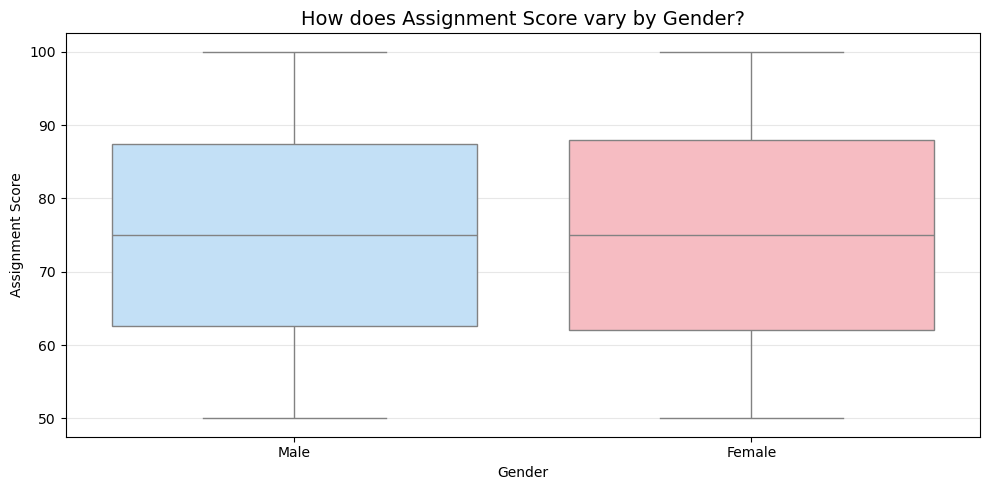

count    21201.000000
mean        74.974982
std         14.525428
min         50.000000
25%         62.300000
50%         75.000000
75%         87.800000
max        100.000000
Name: Assignment_Score, dtype: float64

Analyzing column: Attendance_Score


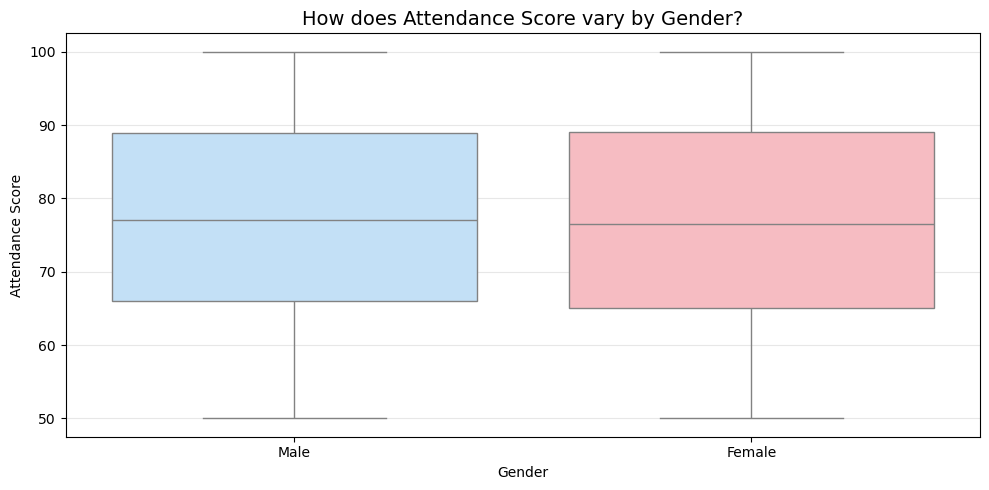

count    21201.000000
mean        76.669992
std         13.917029
min         50.000000
25%         65.000000
50%         77.000000
75%         89.000000
max        100.000000
Name: Attendance_Score, dtype: float64

Analyzing column: Exam_Score


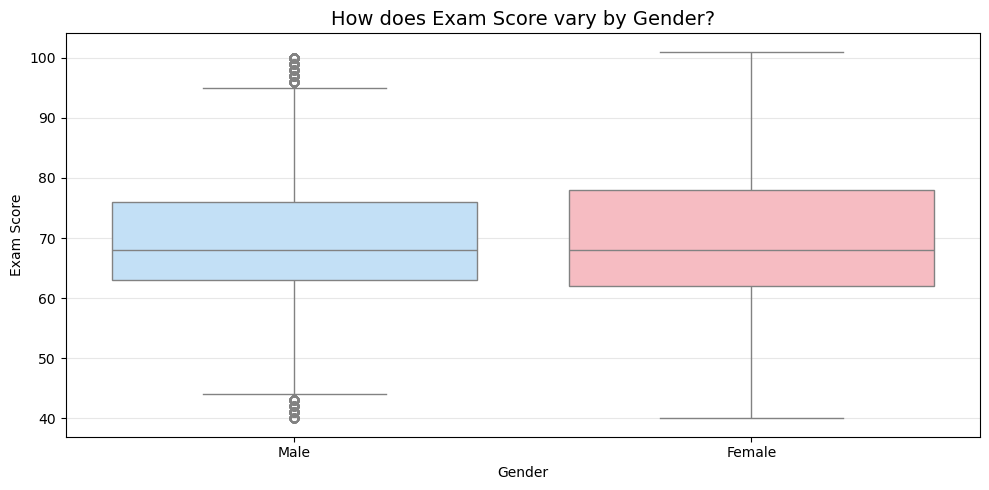

count    21201.000000
mean        69.250366
std         13.516739
min         40.000000
25%         62.000000
50%         68.000000
75%         77.000000
max        101.000000
Name: Exam_Score, dtype: float64

Analyzing column: Total_Score


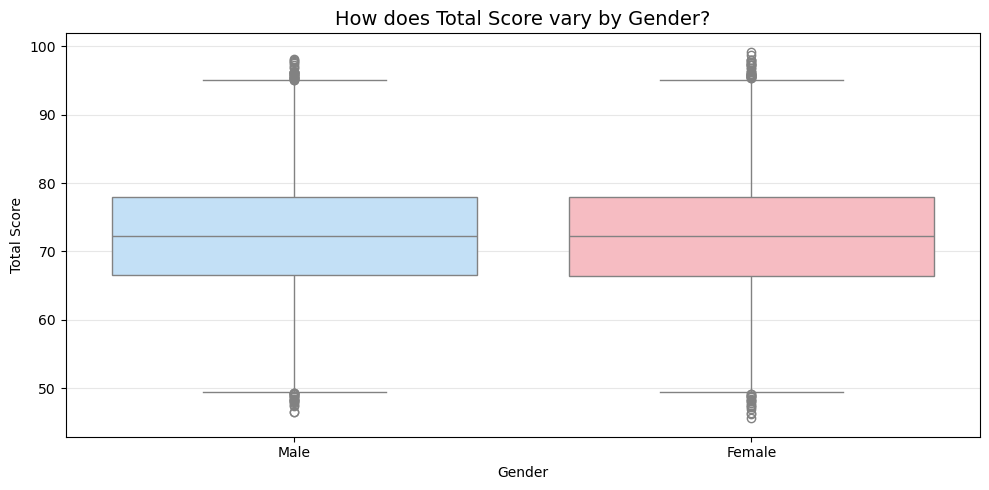

count    21201.000000
mean        72.236031
std          8.455846
min         45.600000
25%         66.500000
50%         72.200000
75%         77.900000
max         99.200000
Name: Total_Score, dtype: float64

Analyzing column: Grade


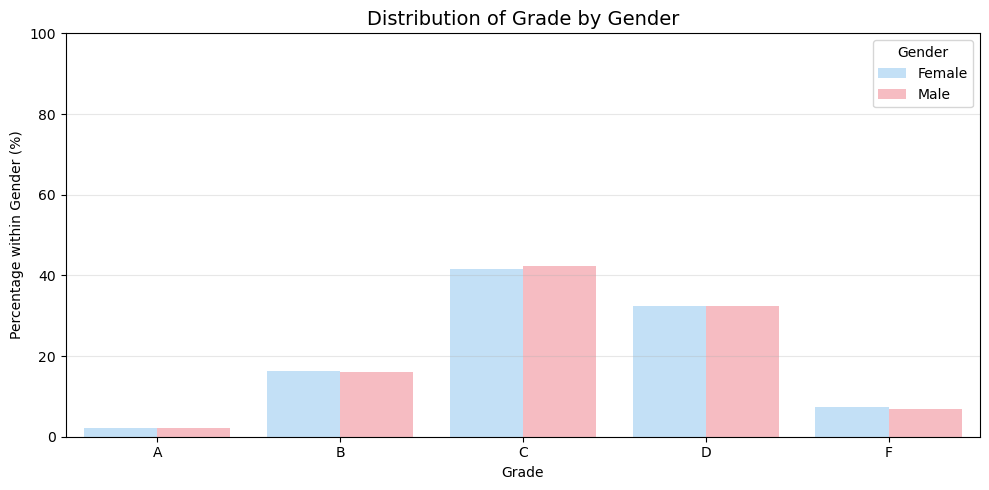

Gender  Female  Male
Grade               
A          220   227
B         1636  1787
C         4198  4714
D         3279  3611
F          755   774

Analyzing column: Participation


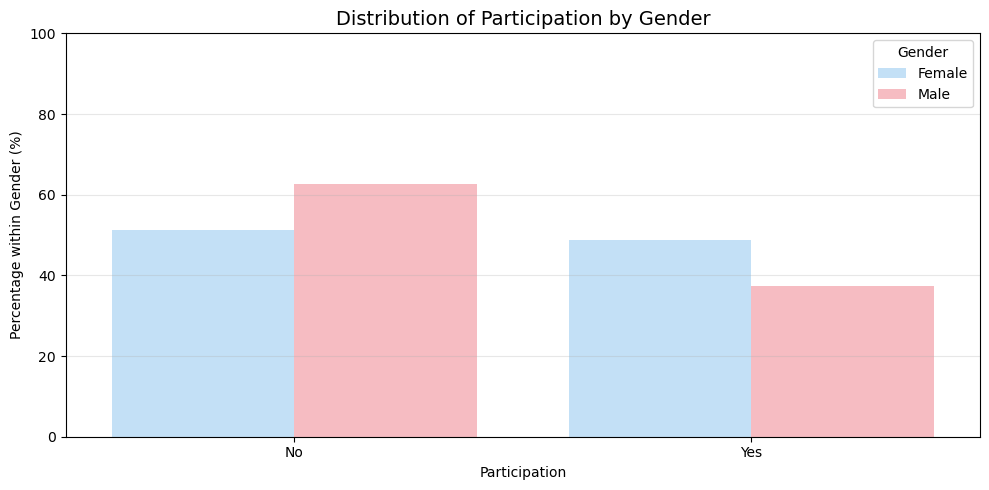

Gender         Female  Male
Participation              
No               5176  6962
Yes              4912  4151


In [14]:
# Visualize Academic features
visualize_category(df_vis, academic_cols)

### 3. Behavior / Lifestyle

In [15]:
behavior_cols = [
    'Study_Hours_per_Week',
    'Social_Media',
    'Sleep_Hours',
    'Physical_Activity',
    'Extracurricular',
    'Stress_Level',
    'Motivation_Level',
    'Peer_Influence'
]


Analyzing column: Study_Hours_per_Week


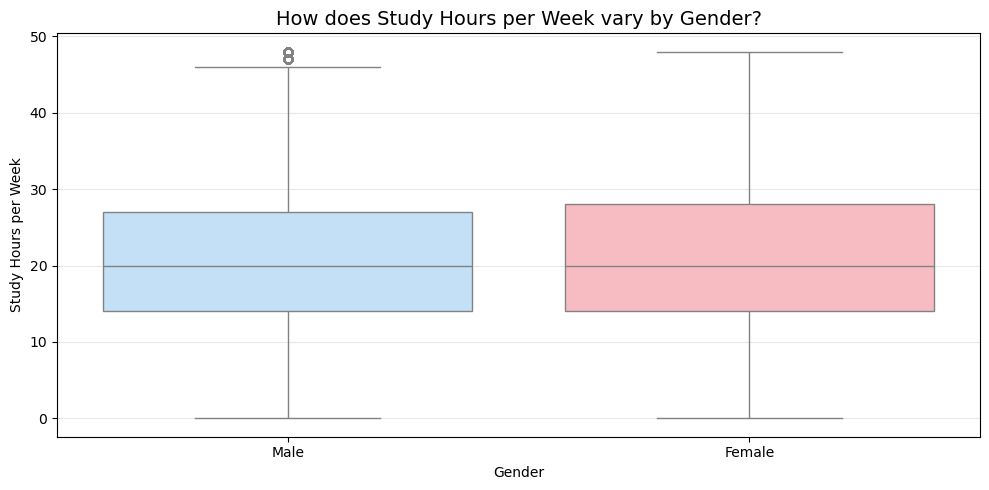

count    21201.000000
mean        21.627753
std         10.835390
min          0.000000
25%         14.000000
50%         20.000000
75%         27.000000
max         48.000000
Name: Study_Hours_per_Week, dtype: float64

Analyzing column: Social_Media


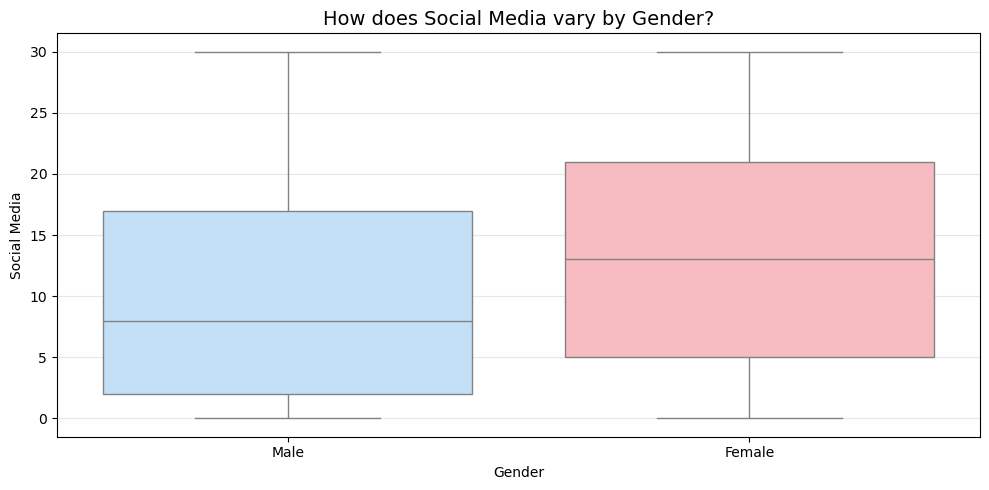

count    21201.000000
mean        11.716193
std          9.384223
min          0.000000
25%          2.000000
50%         11.000000
75%         19.000000
max         30.000000
Name: Social_Media, dtype: float64

Analyzing column: Sleep_Hours


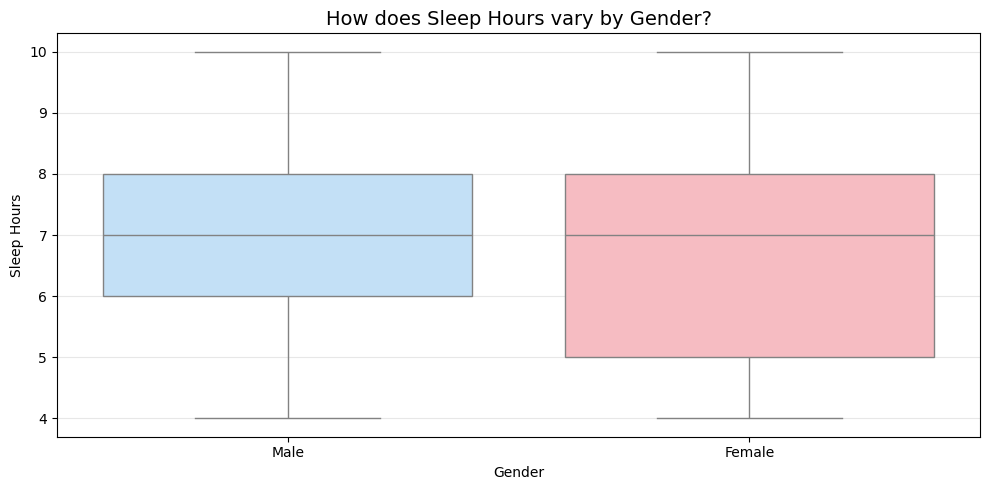

count    21201.000000
mean         6.879581
std          1.746554
min          4.000000
25%          6.000000
50%          7.000000
75%          8.000000
max         10.000000
Name: Sleep_Hours, dtype: float64

Analyzing column: Physical_Activity


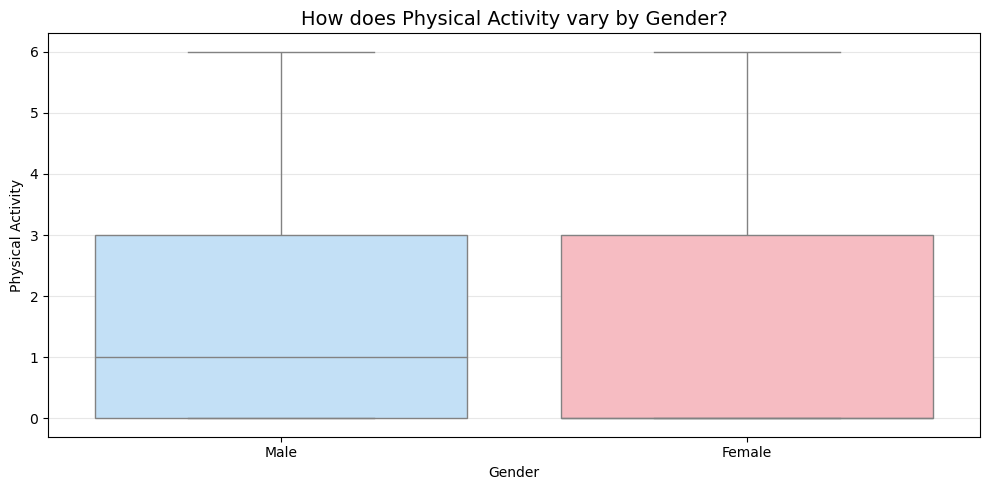

count    21201.000000
mean         1.380878
std          1.754609
min          0.000000
25%          0.000000
50%          0.000000
75%          3.000000
max          6.000000
Name: Physical_Activity, dtype: float64

Analyzing column: Extracurricular


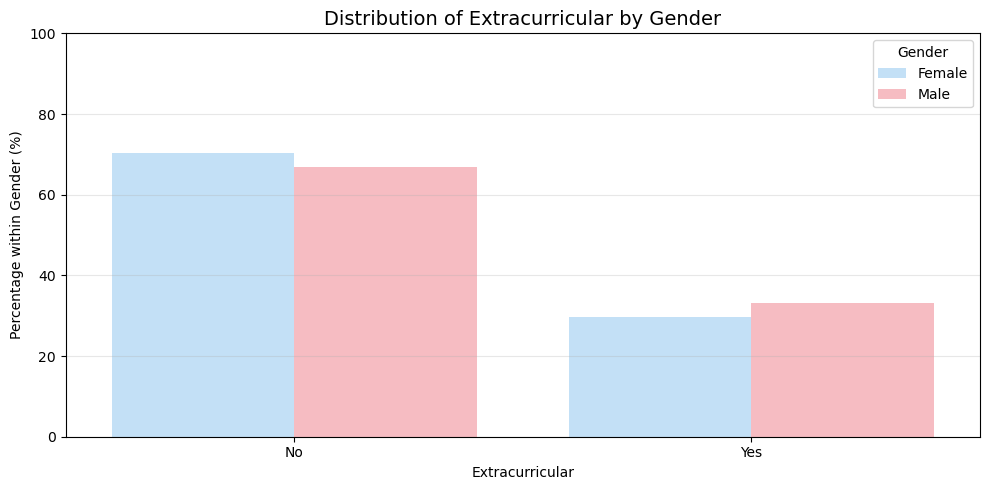

Gender           Female  Male
Extracurricular              
No                 7103  7437
Yes                2985  3676

Analyzing column: Stress_Level


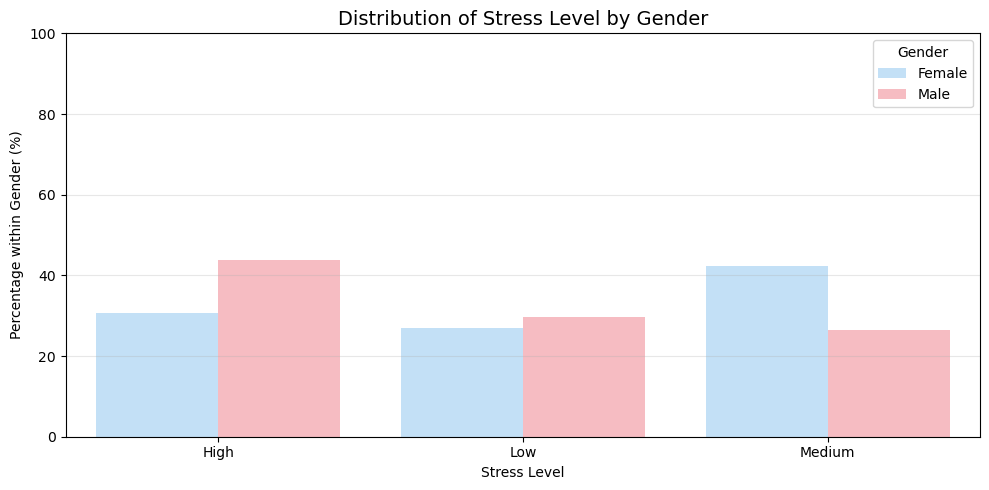

Gender        Female  Male
Stress_Level              
High            3096  4876
Low             2717  3294
Medium          4275  2943

Analyzing column: Motivation_Level


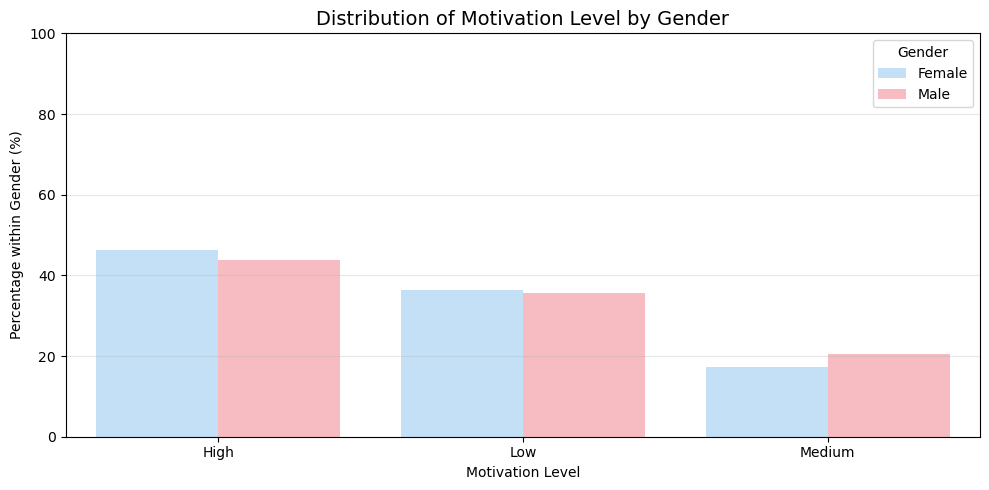

Gender            Female  Male
Motivation_Level              
High                4680  4864
Low                 3660  3969
Medium              1748  2280

Analyzing column: Peer_Influence


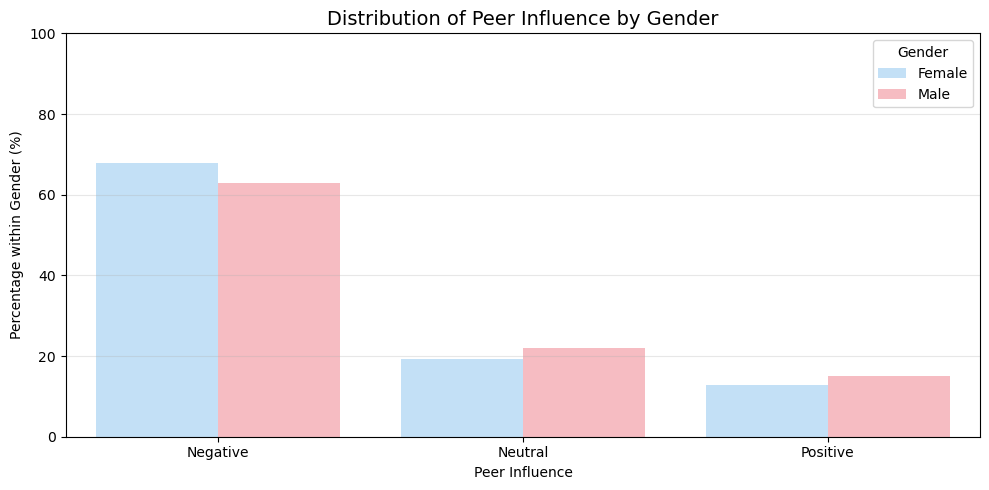

Gender          Female  Male
Peer_Influence              
Negative          6857  7000
Neutral           1949  2443
Positive          1282  1670


In [16]:
# Visualize Behavior features
visualize_category(df_vis, behavior_cols)

### 4. Support / Resources

In [ ]:
support_cols = [
    'Parental_Involvement',
    'Tutoring_Sessions',
    'Resources',
    'Internet',
    'Teacher_Quality'
]


Analyzing column: Parental_Involvement


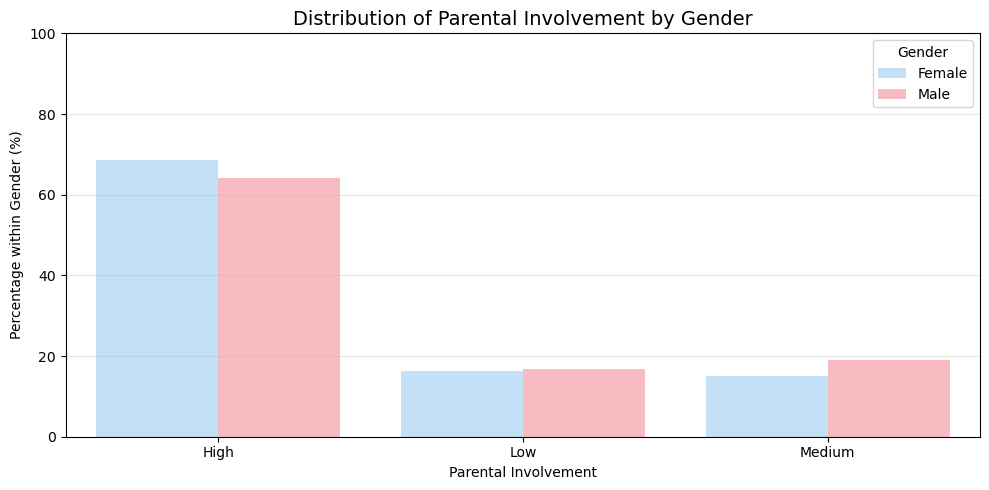

Gender                Female  Male
Parental_Involvement              
High                    6910  7132
Low                     1650  1872
Medium                  1528  2109

Analyzing column: Tutoring_Sessions


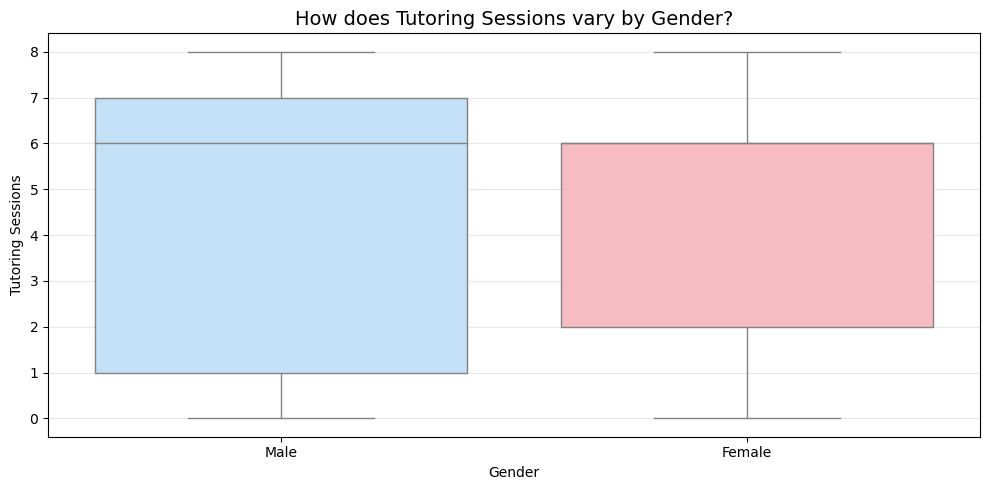

count    21201.000000
mean         4.640111
std          2.671955
min          0.000000
25%          2.000000
50%          6.000000
75%          7.000000
max          8.000000
Name: Tutoring_Sessions, dtype: float64

Analyzing column: Resources


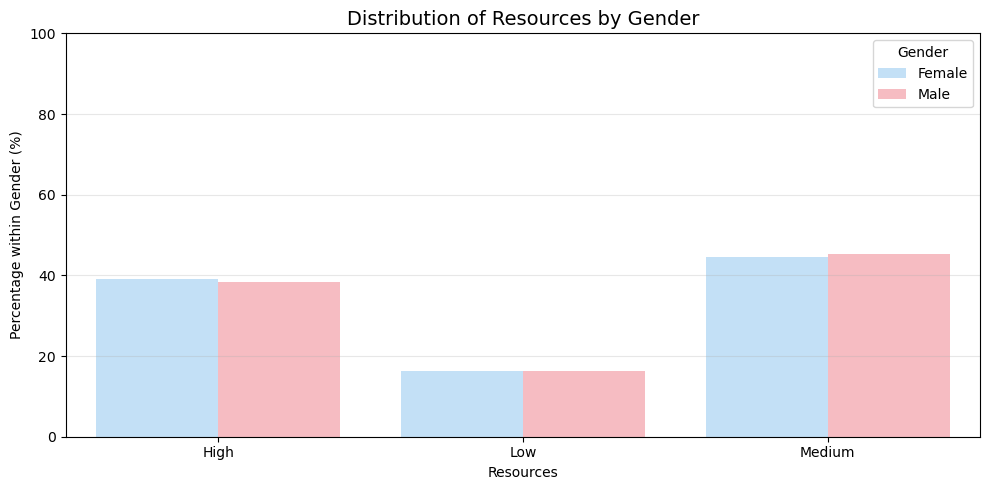

Gender     Female  Male
Resources              
High         3942  4274
Low          1645  1799
Medium       4501  5040

Analyzing column: Internet


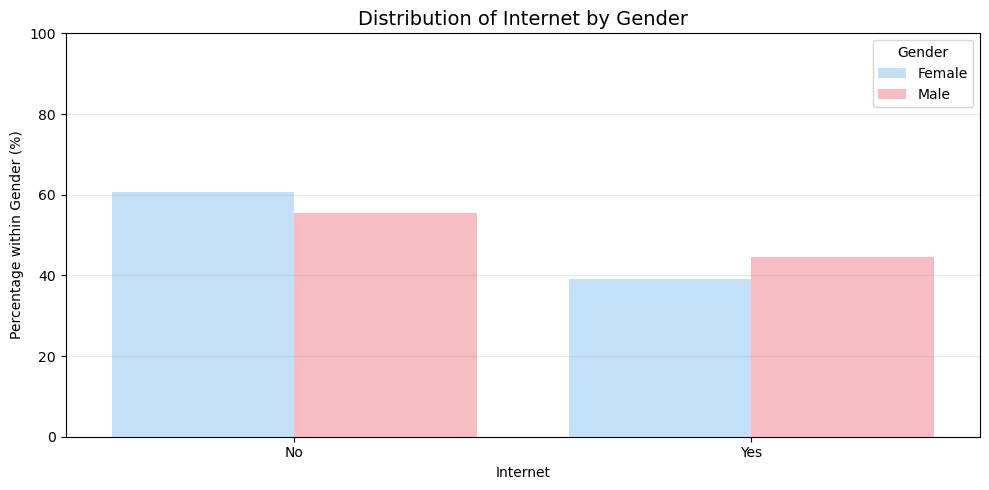

Gender    Female  Male
Internet              
No          6132  6172
Yes         3956  4941

Analyzing column: Teacher_Quality


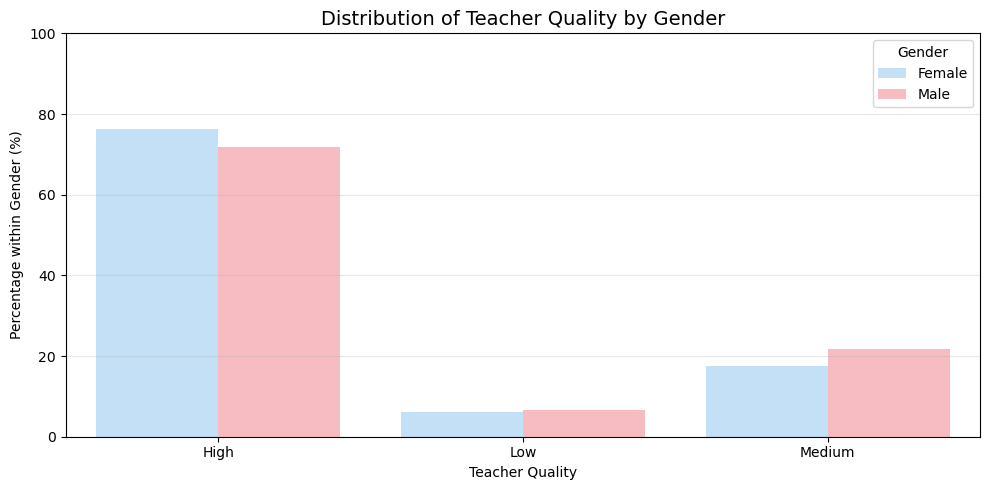

Gender           Female  Male
Teacher_Quality              
High               7698  7977
Low                 612   728
Medium             1778  2408


In [18]:
# Visualize Support features
visualize_category(df_vis, support_cols)

# Feature Engineering
### Classify Student performance into Exceptional, Above-average performance, Average performance, Below-average performance, and Unsatisfactory based on grades.
#### Check which columns have highest correlation/impact with/on Total Scores, and grades:

#### Step 1: Create Student Performance Category

In [19]:
# Copy the dataframe to keep original intact
df_fe = df.copy()

# Define thresholds for High, Medium, Low based on Total_Score
# You can adjust these thresholds if needed
df_fe['Performance'] = pd.cut(
    df_fe['Total_Score'],
    bins=[-1, 60, 80, 100],  # 0-60 Low, 60-80 Medium, 80-100 High
    labels=['Low', 'Medium', 'High']
)

# Quick check
df_fe['Performance'].value_counts()


Performance
Medium    15825
High       3810
Low        1566
Name: count, dtype: int64

#### Step 2: Check correlations (numeric features)

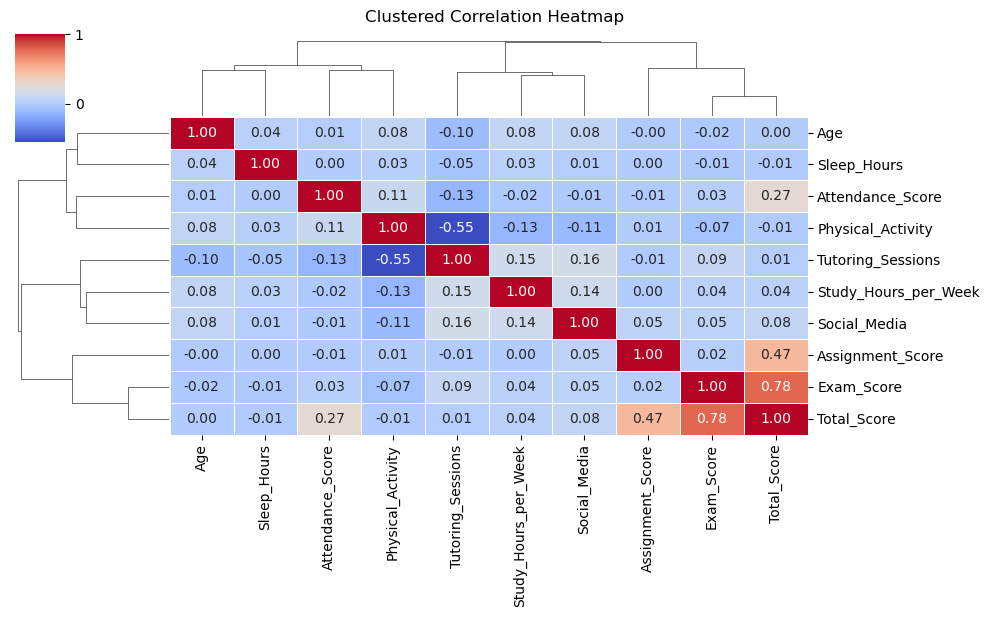

In [20]:
# Select numeric columns (your features + Total_Score)
numeric_cols = ['Age', 'Assignment_Score', 'Attendance_Score', 'Exam_Score', 
                'Study_Hours_per_Week', 'Sleep_Hours', 'Social_Media', 
                'Physical_Activity', 'Tutoring_Sessions', 'Total_Score']

# Subset numeric dataframe
numeric_df = df_fe[numeric_cols]

# Compute correlation matrix
corr = numeric_df.corr()

# Clustered heatmap
sns.clustermap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, method='ward', figsize=(10,6))
plt.suptitle('Clustered Correlation Heatmap', y=1.02)
plt.show()

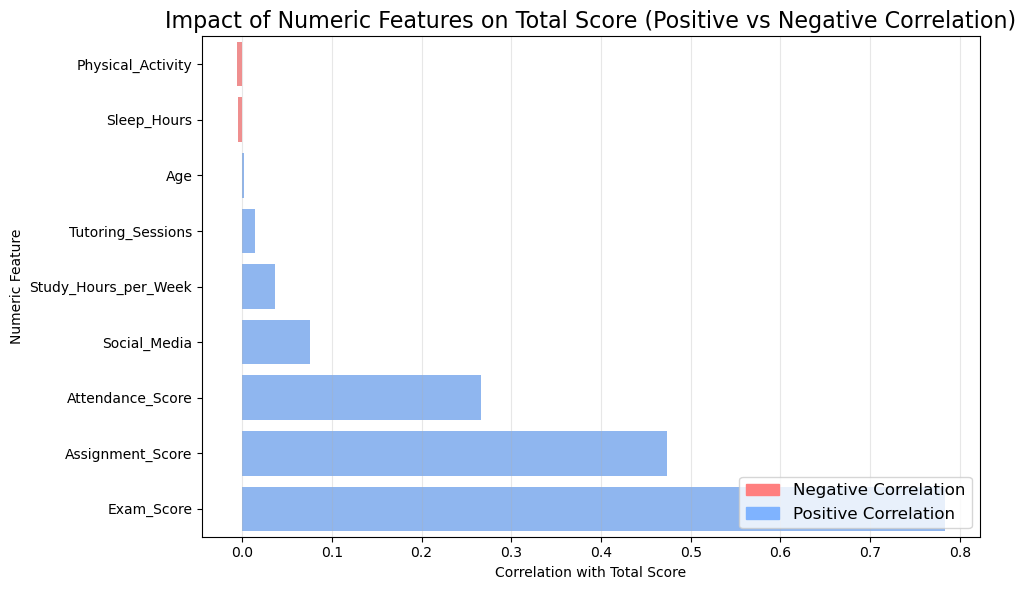

In [21]:
# Ensure 'Total_Score' is included once
numeric_cols_for_corr = list(set(numeric_cols) - {'Total_Score'})  

# Compute correlation with Total_Score
corr_values = df_fe[numeric_cols_for_corr + ['Total_Score']].corr()['Total_Score'].drop('Total_Score')
corr_values = corr_values.sort_values(ascending=True)  # negative on left, positive on right

# Convert to DataFrame for plotting
corr_df = corr_values.reset_index()
corr_df.columns = ['Feature', 'Correlation']

# Barplot
plt.figure(figsize=(10,6))
colors = ['#FF7F7F' if x < 0 else '#7FB3FF' for x in corr_df['Correlation']]  # red=negative, blue=positive
sns.barplot(x='Correlation', y='Feature', data=corr_df, palette=colors)

plt.title('Impact of Numeric Features on Total Score (Positive vs Negative Correlation)', fontsize=16)
plt.xlabel('Correlation with Total Score')
plt.ylabel('Numeric Feature')
plt.grid(alpha=0.3, axis='x')

# Add custom legend
red_patch = mpatches.Patch(color='#FF7F7F', label='Negative Correlation')
blue_patch = mpatches.Patch(color='#7FB3FF', label='Positive Correlation')
plt.legend(handles=[red_patch, blue_patch], loc='lower right', fontsize=12)

plt.tight_layout()
plt.show()

#### Step 3: Check impact of categorical features on Total_Score or Grade

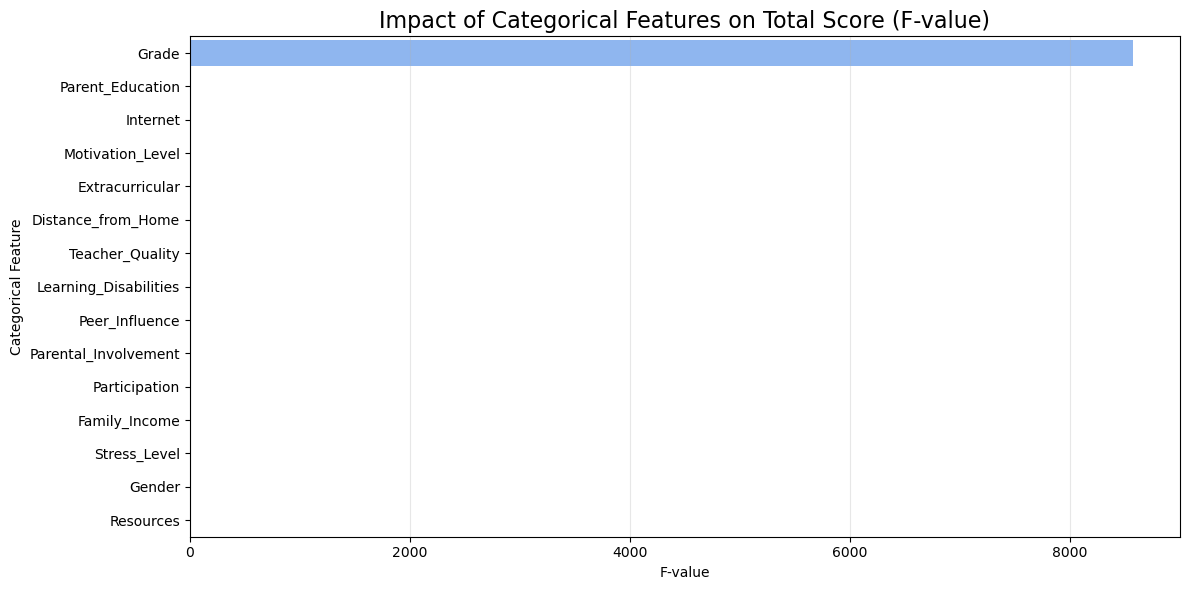

In [22]:
from sklearn.feature_selection import f_classif
categorical_cols = ['Gender', 'Family_Income', 'Distance_from_Home', 'Parent_Education',
                    'Learning_Disabilities', 'Participation', 'Extracurricular', 'Stress_Level', 
                    'Motivation_Level', 'Peer_Influence', 'Parental_Involvement', 'Resources', 
                    'Internet', 'Teacher_Quality', 'Grade']

# Compute ANOVA F-values for each categorical feature
f_values = {}
for col in categorical_cols:
    if df_fe[col].nunique() > 1:
        X = pd.get_dummies(df_fe[col], drop_first=True)
        y = df_fe['Total_Score']
        f_val, p_val = f_classif(X, y)
        f_values[col] = f_val.mean()  # mean F-value across dummy columns

# Convert to DataFrame for plotting
f_df = pd.DataFrame({
    'Feature': list(f_values.keys()),
    'F_value': list(f_values.values())
}).sort_values('F_value', ascending=False)

# Plot
colors = []
for col in categorical_cols:
    X = pd.get_dummies(df_fe[col].astype(str), drop_first=True)
    corr = X.corrwith(df_fe['Total_Score']).mean()
    colors.append('#7FB3FF' if corr >= 0 else '#FF7F7F')  # blue=positive, red=negative

plt.figure(figsize=(12,6))

sns.barplot(x='F_value', y='Feature', data=f_df, palette=colors)
plt.title('Impact of Categorical Features on Total Score (F-value)', fontsize=16)
plt.xlabel('F-value')
plt.ylabel('Categorical Feature')
plt.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

### Data Transformation to achieve Normality
#### log scale to zoom in on smaller impacting features

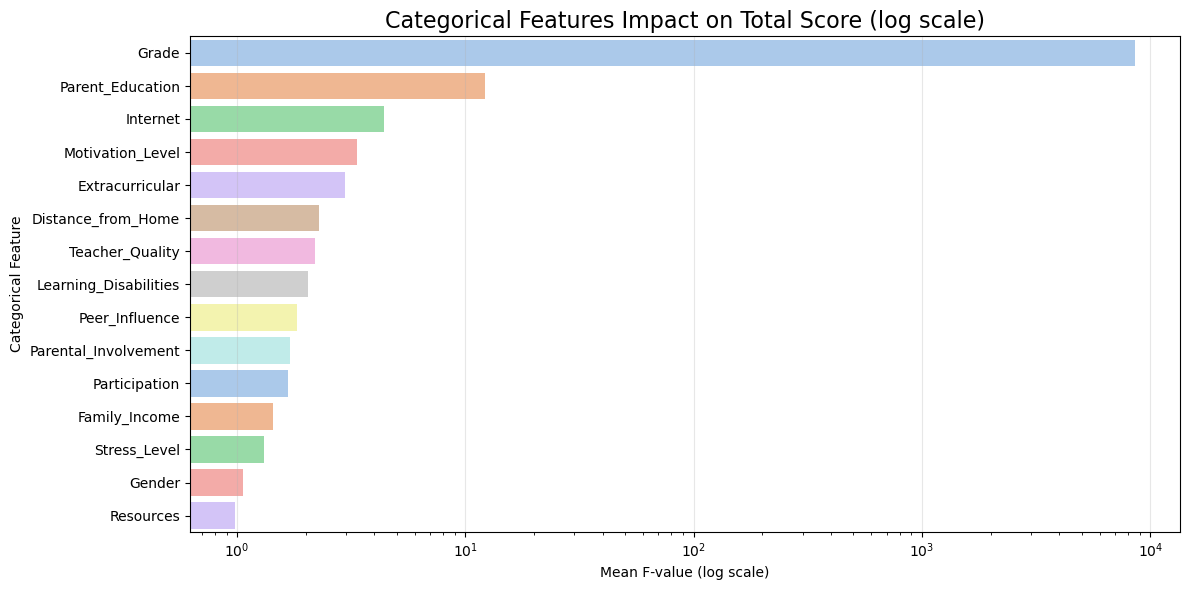

In [23]:
plt.figure(figsize=(12,6))
sns.barplot(x='F_value', y='Feature', data=f_df, palette='pastel')
plt.xscale('log')  # log scale to compress large values
plt.title('Categorical Features Impact on Total Score (log scale)', fontsize=16)
plt.xlabel('Mean F-value (log scale)')
plt.ylabel('Categorical Feature')
plt.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.show()


### Step 4: Cluster Analysis

In [24]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [25]:


# # --- 1️⃣ Load dataset ---
# df = df_fe.copy()  # use your preprocessed dataset

# # --- 2️⃣ Select numeric features for clustering ---
# cluster_features = [
#     'Study_Hours_per_Week', 'Attendance_Score', 'Exam_Score',
#     'Sleep_Hours', 'Social_Media', 'Assignment_Score'
# ]

# # Drop rows with missing values in these features
# df_cluster = df[cluster_features + ['Total_Score']].dropna().copy()

# # --- 3️⃣ Standardize features ---
# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(df_cluster[cluster_features])

# # --- 4️⃣ Run KMeans clustering ---
# kmeans = KMeans(n_clusters=5, random_state=42)
# cluster_labels = kmeans.fit_predict(X_scaled)
# df_cluster['Cluster'] = cluster_labels

# # --- 5️⃣ Compute average study hours for reference ---
# avg_study_hours = df_cluster['Study_Hours_per_Week'].mean()

# # --- 6️⃣ Assign meaningful cluster names based on patterns ---
# def label_clusters(row):
#     study = row['Study_Hours_per_Week']
#     score = row['Total_Score']
#     social = row['Social_Media']
#     sleep = row['Sleep_Hours']
    
#     if study > avg_study_hours and score >= 85:
#         return 'High Performers'
#     elif study <= avg_study_hours and score <= 60 and social >= 10:
#         return 'At-Risk Students'
#     elif study <= avg_study_hours and score >= 80:
#         return 'Low Effort High Achievers'
#     elif study <= avg_study_hours and 65 <= score <= 84:
#         return 'Average Performers'
#     elif sleep >= 9 and 65 <= score <= 80:
#         return 'Balanced Students'
#     else:
#         return 'Mixed Patterns'

# df_cluster['Cluster_Name'] = df_cluster.apply(label_clusters, axis=1)

# # --- 7️⃣ Visualize average feature values per cluster ---
# plt.figure(figsize=(12,6))
# sns.heatmap(
#     df_cluster.groupby('Cluster_Name')[cluster_features].mean().round(1),
#     annot=True, fmt=".1f", cmap='coolwarm'
# )
# plt.title("Average Feature Values per Cluster", fontsize=16)
# plt.xlabel("Feature")
# plt.ylabel("Cluster Name")
# plt.tight_layout()
# plt.show()

# # --- 8️⃣ Visualize cluster distribution (number of students per cluster) ---
# plt.figure(figsize=(10,6))
# sns.countplot(
#     x='Cluster_Name',
#     data=df_cluster,
#     palette='tab10',
#     order=df_cluster['Cluster_Name'].value_counts().index
# )
# plt.title("Student Cluster Distribution", fontsize=16)
# plt.xlabel("Cluster Name")
# plt.ylabel("Number of Students")
# plt.xticks(rotation=45, ha='right')
# plt.grid(alpha=0.3, axis='y')
# plt.tight_layout()
# plt.show()

# # --- 9️⃣ Optional: Print cluster sizes ---
# print("\nCluster sizes by Cluster_Name:")
# print(df_cluster['Cluster_Name'].value_counts())


Selected features for clustering: ['Exam_Score', 'Assignment_Score']

Mean Exam and Assignment scores by cluster:
                           Exam_Score  Assignment_Score
Cluster_Name                                           
At-Risk Students                61.77             62.46
Balanced Students               85.25             61.99
High Performers                 86.13             87.31
Low Effort High Achievers       62.93             87.51


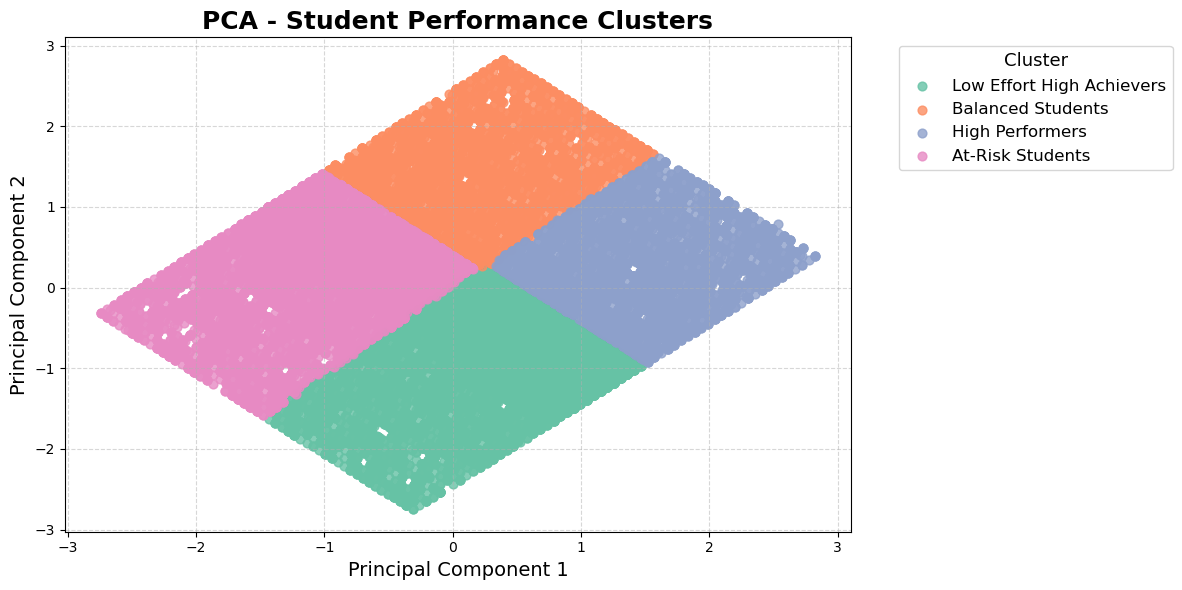


Cluster sizes by descriptive names:
Low Effort High Achievers: 7544 students
Balanced Students: 3133 students
High Performers: 3130 students
At-Risk Students: 7394 students


In [26]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1️⃣ Copy dataset ---
dfe = df_fe.copy()  # your preprocessed dataset

# --- 2️⃣ Automatically select top 2 numeric features most correlated with Total_Score ---
numeric_cols = dfe.select_dtypes(include=np.number).columns.tolist()
numeric_cols.remove('Total_Score')  # exclude target
corr_with_target = dfe[numeric_cols + ['Total_Score']].corr()['Total_Score'].drop('Total_Score')
top_features = corr_with_target.abs().sort_values(ascending=False).head(2).index.tolist()
print(f"Selected features for clustering: {top_features}")

# --- 3️⃣ Standardize features ---
scaler = StandardScaler()
X = scaler.fit_transform(dfe[top_features])

# --- 4️⃣ Perform KMeans clustering ---
n_clusters = 4  # you can adjust
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=100, max_iter=2000)
dfe['Cluster'] = kmeans.fit_predict(X)

# --- 5️⃣ Apply PCA for visualization ---
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
dfe['PCA1'] = X_pca[:, 0]
dfe['PCA2'] = X_pca[:, 1]

# --- 6️⃣ Automatically assign descriptive cluster names based on feature means ---
cluster_names = {}
for i in range(n_clusters):
    cluster_data = dfe[dfe['Cluster'] == i]
    means = cluster_data[top_features].mean()
    
    if means[top_features[0]] > dfe[top_features[0]].mean() and means[top_features[1]] > dfe[top_features[1]].mean():
        cluster_names[i] = "High Performers"
    elif means[top_features[0]] < dfe[top_features[0]].mean() and means[top_features[1]] < dfe[top_features[1]].mean():
        cluster_names[i] = "At-Risk Students"
    elif means[top_features[0]] < dfe[top_features[0]].mean() and means[top_features[1]] > dfe[top_features[1]].mean():
        cluster_names[i] = "Low Effort High Achievers"
    elif means[top_features[0]] > dfe[top_features[0]].mean() and means[top_features[1]] < dfe[top_features[1]].mean():
        cluster_names[i] = "Balanced Students"
    else:
        cluster_names[i] = "Mixed Patterns"

# --- 7️⃣ Add cluster name to dataframe ---
dfe['Cluster_Name'] = dfe['Cluster'].map(cluster_names)

# --- 8️⃣ Print summary of Exam & Assignment means ---
if 'Exam_Score' in dfe.columns and 'Assignment_Score' in dfe.columns:
    print("\nMean Exam and Assignment scores by cluster:")
    print(dfe.groupby('Cluster_Name')[['Exam_Score', 'Assignment_Score']].mean().round(2))
else:
    print("\n⚠️ 'Exam_Score' and/or 'Assignment_Score' columns not found in dataframe.")

# --- 9️⃣ Plot clusters ---
plt.figure(figsize=(12, 6))
palette = sns.color_palette("Set2", n_clusters)

for i in range(n_clusters):
    plt.scatter(
        dfe[dfe['Cluster'] == i]['PCA1'],
        dfe[dfe['Cluster'] == i]['PCA2'],
        label=cluster_names[i],
        alpha=0.8,
        s=40,
        color=palette[i],
        marker='o'
    )

plt.xlabel('Principal Component 1', fontsize=14)
plt.ylabel('Principal Component 2', fontsize=14)
plt.title('PCA - Student Performance Clusters', fontsize=18, fontweight='bold')
plt.legend(title='Cluster', fontsize=12, title_fontsize=13, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# --- 🔟 Display cluster sizes ---
print("\nCluster sizes by descriptive names:")
for i, name in cluster_names.items():
    size = len(dfe[dfe['Cluster'] == i])
    print(f"{name}: {size} students")


In [27]:
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns
# from sklearn.preprocessing import StandardScaler, MinMaxScaler
# from sklearn.cluster import KMeans
# from sklearn.metrics import silhouette_score

# # --- 1️⃣ Use your preprocessed dataset ---
# dfe = df_fe.copy()  # your cleaned dataset

# # --- 2️⃣ Select numeric features automatically for clustering ---
# numeric_cols = dfe.select_dtypes(include=np.number).columns.tolist()
# numeric_cols.remove('Total_Score')  # exclude target if present

# # Standardize features
# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(df[numeric_cols])

# # --- 3️⃣ Determine optimal number of clusters automatically (Elbow + Silhouette optional) ---
# n_clusters = 6  # fixed for demonstration; could use elbow/silhouette method here

# # KMeans clustering
# kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=100, max_iter=2000)
# df['Cluster'] = kmeans.fit_predict(X_scaled)

# # --- 4️⃣ Automatically assign descriptive cluster names based on feature means ---
# cluster_names = {}
# for i in range(n_clusters):
#     cluster_data = dfe[dfe['Cluster'] == i]
#     means = cluster_data[numeric_cols].mean()
    
#     high_features = means > dfe[numeric_cols].mean()
#     low_features = ~high_features
    
#     if means['Exam_Score'] > dfe['Exam_Score'].mean() and means['Study_Hours_per_Week'] > dfe['Study_Hours_per_Week'].mean():
#         cluster_names[i] = "High Performers"
#     elif means['Exam_Score'] < dfe['Exam_Score'].mean() and means['Study_Hours_per_Week'] < dfe['Study_Hours_per_Week'].mean():
#         cluster_names[i] = "At-Risk Students"
#     elif means['Exam_Score'] > dfe['Exam_Score'].mean() and means['Study_Hours_per_Week'] < dfe['Study_Hours_per_Week'].mean():
#         cluster_names[i] = "Low Effort High Achievers"
#     elif means['Exam_Score'] < dfe['Exam_Score'].mean() and means['Study_Hours_per_Week'] > dfe['Study_Hours_per_Week'].mean():
#         cluster_names[i] = "Balanced Students"
#     else:
#         cluster_names[i] = "Mixed Patterns"

# dfe['Cluster_Name'] = dfe['Cluster'].map(cluster_names)

# # --- 5️⃣ Radar Chart Visualization ---
# radar_features = numeric_cols[:5]  # top 5 features for readability
# radar_data = dfe.groupby('Cluster')[radar_features].mean()
# radar_data_norm = MinMaxScaler().fit_transform(radar_data)
# angles = np.linspace(0, 2*np.pi, len(radar_features), endpoint=False).tolist()
# angles += angles[:1]

# palette = sns.color_palette("Set2", n_clusters)
# plt.figure(figsize=(15, 8))
# for i in range(n_clusters):
#     values = radar_data_norm[i].tolist()
#     values += values[:1]
#     ax = plt.subplot(2, 3, i+1, polar=True)
#     ax.plot(angles, values, 'o-', linewidth=2, color=palette[i], label=f'Cluster {i}')
#     ax.fill(angles, values, alpha=0.25, color=palette[i])
#     ax.set_xticks(angles[:-1])
#     ax.set_xticklabels(radar_features, fontsize=11)
#     ax.set_title(f'{cluster_names[i]} (Cluster {i})', fontsize=12, fontweight='bold')
#     ax.grid(alpha=0.3)
# plt.suptitle('Radar Charts of Cluster Profiles', fontsize=15, fontweight='bold')
# plt.tight_layout(rect=[0, 0.03, 1, 0.95])
# plt.show()

# # --- 6️⃣ Heatmap of All Feature Means by Cluster ---
# plt.figure(figsize=(12, 7))
# all_means = df.groupby('Cluster')[numeric_cols].mean()
# sns.heatmap(all_means, annot=True, fmt='.1f', cmap='YlGnBu', linewidths=0.5, cbar_kws={'label': 'Mean Value'})
# plt.title('Cluster Feature Means Heatmap', fontsize=15, fontweight='bold')
# plt.ylabel('Cluster', fontsize=13)
# plt.xlabel('Feature', fontsize=13)
# plt.xticks(fontsize=11, rotation=35)
# plt.yticks(fontsize=11)
# plt.tight_layout()
# plt.show()

# # --- 7️⃣ Cluster sizes ---
# print("\nCluster sizes by descriptive names:")
# for i, name in cluster_names.items():
#     size = len(df[df['Cluster'] == i])
#     print(f"{name}: {size} students")


# Linear Regression

Fit a linear regression Model to predict the <code>'Total Score'</code> using the list of features then calculate R^2

In [28]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler,PolynomialFeatures
from sklearn.linear_model import LinearRegression

In [29]:
# Select numeric columns
df_numeric = df.select_dtypes(include=[np.number])

# Define X (features) and Y (target)
X = df_numeric.drop(columns=['Total_Score'])
Y = df_numeric['Total_Score'] 

lm = LinearRegression()
lm.fit(X, Y)

r_squared = lm.score(X, Y)
print("R^2 value:", r_squared)

R^2 value: 0.8856385298485162


#### Create list of tupples, estimators and model constructors

In [ ]:
Input=[('scale',StandardScaler()),('polynomial', PolynomialFeatures(include_bias=False)),('model',LinearRegression())]

#### Use the list to create a pipeline object to predict the 'Total_Score', fit the object using the features in the variable <code>df_numeric</code>, and calculate the R^2. Take a screenshot of your code and the value of the R^2. 

In [31]:
pipe = Pipeline(Input)

# Define features and target
X = df_numeric.drop(columns=['Total_Score'])
Y = df_numeric['Total_Score'] 

# Fit the pipeline to the data
pipe.fit(X, Y)

# Calculate R^2
r_squared = pipe.score(X, Y)
print("R^2 value:", r_squared)

R^2 value: 0.8962211473188019


# Model Evaluation and Refinement

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split

In [33]:
X = df_numeric.drop(columns=['Total_Score'])
Y = df_numeric['Total_Score'] 

x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.15, random_state=1)


print("number of test samples:", x_test.shape[0])
print("number of training samples:",x_train.shape[0])

number of test samples: 3181
number of training samples: 18020


#### Create and fit a Ridge regression object using the training data, set the regularization parameter to 0.1, and calculate the R^2 using the test data. 

In [34]:
from sklearn.linear_model import Ridge

In [35]:
ridge_model = Ridge(alpha=0.1)

ridge_model.fit(x_train, y_train)

r_squared = ridge_model.score(x_test, y_test)
print("R^2 value on test data:", r_squared)

R^2 value on test data: 0.8766213247692344


#### Perform a second order polynomial transform on both the training data and testing data. Create and fit a Ridge regression object using the training data, set the regularisation parameter to 0.1, and calculate the R^2 utilising the test data provided.

In [36]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, include_bias=False)

x_train_poly = poly.fit_transform(x_train)
x_test_poly = poly.transform(x_test)

ridge_model = Ridge(alpha=0.1)
ridge_model.fit(x_train_poly, y_train)

r_squared = ridge_model.score(x_test_poly, y_test)
print("R^2 value on test data with polynomial features:", r_squared)

R^2 value on test data with polynomial features: 0.8883135366136362


#  Test ML Regression Models

In [37]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

In [38]:
X = df.drop(columns=['Total_Score'])
y = df['Total_Score']

#### Convert categorical columns to numerical using one-hot encoding

In [39]:
X = pd.get_dummies(X, drop_first=True)

In [40]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 537)

#### Define regression models and their hyperparameters for GridSearchCV

In [ ]:
regression_models = {
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(),
    'Lasso': Lasso(),
    'ElasticNet': ElasticNet(),
    'DecisionTreeRegressor': DecisionTreeRegressor(),
    'RandomForestRegressor': RandomForestRegressor(),
    'GradientBoostingRegressor': GradientBoostingRegressor(),
    'AdaBoostRegressor': AdaBoostRegressor(),
    'SVR': SVR(),
    'KNeighborsRegressor': KNeighborsRegressor()
}

regression_params = {
    'LinearRegression': {},
    'Ridge': {'alpha': [0.01, 0.1, 1.0, 10.0]},
    'Lasso': {'alpha': [0.01, 0.1, 1.0, 10.0]},
    'ElasticNet': {'alpha': [0.01, 0.1, 1.0], 'l1_ratio': [0.2, 0.5, 0.8]},
    'DecisionTreeRegressor': {'max_depth': [None, 10, 20], 'min_samples_split': [2, 5]},
    'RandomForestRegressor': {'n_estimators': [50, 100], 'max_depth': [None, 10]},
    'GradientBoostingRegressor': {'n_estimators': [50, 100], 'learning_rate': [0.01, 0.1]},
    'AdaBoostRegressor': {'n_estimators': [50, 100], 'learning_rate': [0.01, 0.1]},
    'SVR': {'C': [0.01, 0.1, 1.0], 'kernel': ['linear', 'rbf']},
    'KNeighborsRegressor': {'n_neighbors': [3, 5]}
}

#### Train and evaluate regression models using GridSearchCV

In [42]:
# regression_results = []
# for model_name in regression_models:
#     grid_search = GridSearchCV(regression_models[model_name], regression_params[model_name], cv=5)
#     grid_search.fit(X_train, y_train)
    
#     best_model = grid_search.best_estimator_
    
#     y_pred_train = best_model.predict(X_train)
#     y_pred_test = best_model.predict(X_test)
    
#     train_r2_score = r2_score(y_train, y_pred_train)
#     test_r2_score = r2_score(y_test, y_pred_test)
    
#     regression_results.append({
#         'Model': model_name,
#         'Best Parameters': grid_search.best_params_,
#         'Train R2 Score': train_r2_score,
#         'Test R2 Score': test_r2_score,
#         'Train MSE': mean_squared_error(y_train, y_pred_train),
#         'Test MSE': mean_squared_error(y_test, y_pred_test)
#     })

In [ ]:
regression_results = []

for model_name in regression_models:
    grid_search = GridSearchCV(regression_models[model_name], regression_params[model_name], cv=5)
    grid_search.fit(X_train, y_train)
    
    best_model = grid_search.best_estimator_
    y_pred_train = best_model.predict(X_train)
    
    train_r2_score = r2_score(y_train, y_pred_train)
    train_mse = mean_squared_error(y_train, y_pred_train)
    
    regression_results.append({
        'Model': model_name,
        'Best Parameters': grid_search.best_params_,
        'Train R2 Score': train_r2_score,
        'Train MSE': train_mse
    })


In [ ]:
for i, model_name in enumerate(regression_models):
    best_model = GridSearchCV(
        regression_models[model_name], regression_params[model_name], cv=5
    ).fit(X_train, y_train).best_estimator_
    
    y_pred_test = best_model.predict(X_test)
    
    test_r2_score = r2_score(y_test, y_pred_test)
    test_mse = mean_squared_error(y_test, y_pred_test)
    
    # Update existing dictionary entry
    regression_results[i].update({
        'Test R2 Score': test_r2_score,
        'Test MSE': test_mse
    })


#### Convert regression results to DataFrame and display it

In [ ]:
regression_results_df = pd.DataFrame(regression_results)
regression_results_df

#### Plot regression results

In [ ]:
sns.barplot(x='Model', y='Train R2 Score', data=regression_results_df)
plt.title('Regression Models Train R2 Score')
plt.xticks(rotation=45)
plt.show()

In [ ]:
plt.figure(figsize=(12, 8))
sns.barplot(x='Model', y='Test R2 Score', data=regression_results_df)
plt.title('Regression Models Test R2 Score')
plt.xticks(rotation=45)
plt.show()

In [ ]:
sns.barplot(x='Model', y='Train MSE', data=regression_results_df)
plt.title('Regression Models Train MSE')
plt.xticks(rotation=45)
plt.show()

In [ ]:
sns.barplot(x='Model', y='Test MSE', data=regression_results_df)
plt.title('Regression Models Test MSE')
plt.xticks(rotation=45)
plt.show()

# Test ML Classification Models and Find the Best Parameters

In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, BaggingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
X = df.drop(columns=['Total_Score'])
y = df['Total_Score']

In [ ]:
X = pd.get_dummies(X, drop_first=True)

#### Scale the data

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=537)

#### Define classification models and their hyperparameters for GridSearchCV

In [ ]:
classification_models = {
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'Gradient Boosting': GradientBoostingClassifier(),
    'AdaBoost': AdaBoostClassifier(),
    'Bagging': BaggingClassifier(),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Support Vector Machine': SVC(),
    'Naive Bayes': GaussianNB(),
}

classification_params = {
    'Decision Tree': {'max_depth': [3, 5, 7]},
    'Random Forest': {'n_estimators': [50, 100], 'max_depth': [3, 5]},
    'Gradient Boosting': {'n_estimators': [50, 100], 'learning_rate': [0.01, 0.1]},
    'AdaBoost': {'n_estimators': [50, 100], 'learning_rate': [0.01, 0.1]},
    'Bagging': {'n_estimators': [50, 100]},
    'K-Nearest Neighbors': {'n_neighbors': [3, 5]},
    'Support Vector Machine': {'C': [0.01, 0.1, 1], 'kernel': ['linear', 'rbf']},
}

# classification_results = []

# for model_name in classification_models:
#     model = classification_models[model_name]
    
#     if model_name in classification_params:
#         grid_search = GridSearchCV(model, classification_params[model_name], cv=5)
#         grid_search.fit(X_train, y_train)
#         best_model = grid_search.best_estimator_
#         best_params = grid_search.best_params_
#         training_time = grid_search.refit_time_
#         y_pred = best_model.predict(X_test)
#         accuracy = accuracy_score(y_test, y_pred)
#         classification_results.append([model_name, best_params, training_time, accuracy])
        
        
#         # classification_report(y_test, y_pred)
        
  
            
# classification_results_df = pd.DataFrame(classification_results, columns=['Model', 'Best Parameters', 'Training Time (s)', 'Accuracy'])

# classification_results_df

In [ ]:
classification_results = []
best_classification_models = {}  # to store fitted models

for model_name in classification_models:
    model = classification_models[model_name]
    
    if model_name in classification_params:
        grid_search = GridSearchCV(model, classification_params[model_name], cv=5)
        grid_search.fit(X_train, y_train)
        
        best_model = grid_search.best_estimator_
        best_params = grid_search.best_params_
        training_time = grid_search.refit_time_
        
        # store the model for reuse in testing cell
        best_classification_models[model_name] = best_model
        
        classification_results.append({
            'Model': model_name,
            'Best Parameters': best_params,
            'Training Time (s)': training_time
        })


In [ ]:
for i, model_name in enumerate(best_classification_models):
    best_model = best_classification_models[model_name]
    y_pred = best_model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    
    # update existing dict entry
    classification_results[i].update({'Accuracy': accuracy})
    
# convert to DataFrame
classification_results_df = pd.DataFrame(classification_results)
classification_results_df

#### Plot classification results

In [ ]:
plt.figure(figsize=(12, 8))
sns.barplot(x='Model', y='Accuracy', data=classification_results_df)
plt.title('Classification Models Accuracy')
plt.xticks(rotation=45)
plt.show()

In [ ]:
plt.figure(figsize=(12, 8))
sns.barplot(x='Model', y='Training Time (s)', data=classification_results_df)
plt.title('Classification Models Training Time')
plt.xticks(rotation=45)
plt.show()